# Recommender Evaluation Comparison Plots

This notebook is focused on per-client comparison plots and one aggregate comparison plot for the selected runs.


In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

try:
    import matplotlib.pyplot as plt
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "matplotlib is required for this notebook. Install it in the active notebook environment."
    ) from exc

try:
    import numpy as np
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "numpy is required for this notebook. Install it in the active notebook environment."
    ) from exc

try:
    import pandas as pd
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "pandas is required for this notebook. Install it in the active notebook environment."
    ) from exc

from IPython.display import Markdown, display

plt.style.use("default")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)


In [2]:
candidate_roots = [Path.cwd(), Path.cwd().parent]
REPO_ROOT = next(
    (
        root
        for root in candidate_roots
        if (root / "federated").exists() and (root / "notebooks").exists()
    ),
    None,
)
if REPO_ROOT is None:
    raise FileNotFoundError(
        "Could not locate the repository root. Run this notebook from the repo root or the notebooks directory."
    )


def infer_run_title(run_id: str) -> str:
    match = re.search(r"logistic_regression-(\d+)clients-alpha([0-9.]+)-seed(\d+)", run_id)
    if match is None:
        return run_id
    clients, alpha, seed = match.groups()
    return f"K={clients}, alpha={alpha}, seed={seed}, model=logistic regression"


def load_run_configs() -> list[dict[str, str]]:
    submit_script = REPO_ROOT / "scripts" / "submit_pipeline.sh"
    text = submit_script.read_text(encoding="utf-8")
    run_ids = []
    seen = set()
    for run_id in re.findall(r'"(federated-training-[^"]+)"', text):
        if run_id in seen:
            continue
        seen.add(run_id)
        run_ids.append(run_id)
    return [{"title": infer_run_title(run_id), "run_id": run_id} for run_id in run_ids]


RUN_CONFIGS = load_run_configs()
SELECTION_ID = "test__max-40__seed-42"
RUN_TYPE = "dirichlet_sampled"  # "dirichlet_sampled" or "default"
DEFAULT_PERSONA = "lay"
PERSONA_BY_RUN_TYPE = {
    "default": DEFAULT_PERSONA,
    "dirichlet_sampled": "dirichlet_sampled",
}
if RUN_TYPE not in PERSONA_BY_RUN_TYPE:
    choices = ", ".join(sorted(PERSONA_BY_RUN_TYPE))
    raise ValueError(f"Unsupported RUN_TYPE={RUN_TYPE!r}. Available: {choices}")
PERSONA = PERSONA_BY_RUN_TYPE[RUN_TYPE]
RECOMMENDER_DIRNAME = "svm_rank_fedavg"
MODE_ORDER = ["plain", "secure", "clustered"]
MODE_LABELS = {
    "plain": "Plain",
    "secure": "Secure",
    "clustered": "Clustered",
}
MODE_COLORS = {
    "plain": "#4c956c",
    "secure": "#2a6fbb",
    "clustered": "#d17a22",
}
PERSONA_ORDER = ["lay", "clinician", "regulator"]
PERSONA_COLORS = {
    "lay": "#5f0f40",
    "clinician": "#0f4c5c",
    "regulator": "#e36414",
}
METRICS = [
    ("pearson_at_3", "Pearson@3"),
    ("pearson_at_5", "Pearson@5"),
    ("pearson_at_8", "Pearson@8"),
]
REPO_ROOT


PosixPath('/gpfs/helios/home/kelemnegasi/fed-xai/fed-perso-xai')

In [3]:
def normalize_run_id(run_id: str) -> str:
    normalized = str(run_id).strip().rstrip("/")
    marker = "federated/runs/"
    if marker in normalized:
        normalized = normalized.split(marker, 1)[1]
    if "/" in normalized:
        normalized = Path(normalized).name
    return normalized


def run_root(run_id: str) -> Path:
    normalized_run_id = normalize_run_id(run_id)
    return REPO_ROOT / "federated" / "runs" / normalized_run_id


def evaluation_summary_path(run_id: str, mode: str) -> Path:
    return (
        run_root(run_id)
        / "recommender_training"
        / SELECTION_ID
        / PERSONA
        / RECOMMENDER_DIRNAME
        / mode
        / "evaluation_summary.json"
    )


def persona_assignment_path(run_id: str) -> Path:
    return run_root(run_id) / "recommender_labels" / SELECTION_ID / PERSONA / "persona_assignment.json"


def cluster_manifest_path(run_id: str) -> Path:
    return (
        run_root(run_id)
        / "recommender_training"
        / SELECTION_ID
        / PERSONA
        / RECOMMENDER_DIRNAME
        / "clustered"
        / "clustering"
        / "manifest.json"
    )


def load_json(path: Path) -> dict[str, object]:
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)


def load_summary(run_id: str, mode: str) -> dict[str, object]:
    normalized_run_id = normalize_run_id(run_id)
    path = evaluation_summary_path(normalized_run_id, mode)
    if not path.exists():
        raise FileNotFoundError(f"Missing evaluation summary for run_id={normalized_run_id}, mode={mode}: {path}")
    payload = load_json(path)
    payload["artifact_path"] = str(path)
    payload["mode"] = mode
    payload["run_id"] = normalized_run_id
    return payload


def load_run_data(run_id: str) -> dict[str, dict[str, object]]:
    return {mode: load_summary(run_id, mode) for mode in MODE_ORDER}


def load_persona_assignment(run_id: str) -> dict[str, object]:
    path = persona_assignment_path(run_id)
    if not path.exists():
        raise FileNotFoundError(f"Missing persona assignment for run_id={normalize_run_id(run_id)}: {path}")
    payload = load_json(path)
    payload["artifact_path"] = str(path)
    return payload


def load_cluster_manifest(run_id: str) -> dict[str, object]:
    path = cluster_manifest_path(run_id)
    if not path.exists():
        raise FileNotFoundError(f"Missing cluster manifest for run_id={normalize_run_id(run_id)}: {path}")
    payload = load_json(path)
    payload["artifact_path"] = str(path)
    return payload


def comparison_frame(run_data: dict[str, dict[str, object]], metric: str) -> pd.DataFrame:
    merged: pd.DataFrame | None = None
    for mode in MODE_ORDER:
        client_df = pd.DataFrame(run_data[mode].get("clients", []))
        if client_df.empty or metric not in client_df.columns:
            continue
        current = (
            client_df[["client_id", metric]]
            .rename(columns={metric: MODE_LABELS[mode]})
            .sort_values("client_id")
            .reset_index(drop=True)
        )
        merged = current if merged is None else merged.merge(current, on="client_id", how="outer")

    if merged is None:
        return pd.DataFrame()
    return merged.sort_values("client_id").reset_index(drop=True)


def aggregate_frame(run_data: dict[str, dict[str, object]]) -> pd.DataFrame:
    rows = []
    for mode in MODE_ORDER:
        aggregate = run_data[mode].get("aggregate", {})
        for metric, metric_label in METRICS:
            value = aggregate.get(metric)
            rows.append(
                {
                    "mode": mode,
                    "mode_label": MODE_LABELS[mode],
                    "metric": metric,
                    "metric_label": metric_label,
                    "value": float(value) if value is not None else np.nan,
                }
            )
    return pd.DataFrame(rows)


def persona_assignment_frame(assignment: dict[str, object]) -> pd.DataFrame:
    client_payload = assignment.get("clients", {})
    rows = []
    for client_id, payload in sorted(client_payload.items()):
        rows.append(
            {
                "client_id": client_id,
                "persona": payload.get("sampled_client_persona"),
                "argmax_persona": payload.get("argmax_persona"),
            }
        )
    return pd.DataFrame(rows)


def cluster_alignment_frames(assignment: dict[str, object], cluster_manifest: dict[str, object]) -> tuple[pd.DataFrame, pd.DataFrame]:
    persona_df = persona_assignment_frame(assignment)
    cluster_series = pd.Series(cluster_manifest.get("final_cluster_assignments", {}), name="cluster_id")
    cluster_df = cluster_series.rename_axis("client_id").reset_index()
    merged = persona_df.merge(cluster_df, on="client_id", how="left").sort_values("client_id").reset_index(drop=True)
    contingency = pd.crosstab(merged["persona"], merged["cluster_id"], dropna=False).reindex(PERSONA_ORDER, fill_value=0)
    return merged, contingency


def plot_metric_comparison(title: str, run_id: str, run_data: dict[str, dict[str, object]], metric: str, metric_label: str) -> None:
    plot_df = comparison_frame(run_data, metric)
    display(Markdown(f"### {metric_label}"))
    if plot_df.empty:
        display(Markdown(f"_{metric_label} is not available for run_id `{run_id}`._"))
        return

    mode_columns = [MODE_LABELS[mode] for mode in MODE_ORDER if MODE_LABELS[mode] in plot_df.columns]
    x_positions = np.arange(len(plot_df))
    width = 0.78 / max(len(mode_columns), 1)

    fig, ax = plt.subplots(figsize=(max(12, len(plot_df) * 0.85), 5.8))
    for idx, column in enumerate(mode_columns):
        mode = next(mode_name for mode_name, label in MODE_LABELS.items() if label == column)
        offset = (idx - (len(mode_columns) - 1) / 2) * width
        values = pd.to_numeric(plot_df[column], errors="coerce")
        ax.bar(
            x_positions + offset,
            values,
            width=width,
            label=column,
            color=MODE_COLORS[mode],
            alpha=0.92,
        )

    ax.set_xticks(x_positions)
    ax.set_xticklabels(plot_df["client_id"], rotation=45, ha="right")
    ax.set_xlabel("Client")
    ax.set_ylabel(metric_label)
    ax.set_ylim(-1.0, 1.0)
    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.set_title(f"{metric_label} per-client comparison | {title}")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_average_comparison(title: str, run_id: str, run_data: dict[str, dict[str, object]]) -> None:
    plot_df = aggregate_frame(run_data)
    display(Markdown("### Average Pearson@3, Pearson@5, and Pearson@8"))
    if plot_df.empty or plot_df["value"].isna().all():
        display(Markdown(f"_Aggregate Pearson values are not available for run_id `{run_id}`._"))
        return

    metric_labels = [metric_label for _, metric_label in METRICS]
    x_positions = np.arange(len(metric_labels))
    width = 0.2 / len(MODE_ORDER)

    fig, ax = plt.subplots(figsize=(9.0, 5.8))
    for idx, mode in enumerate(MODE_ORDER):
        mode_df = plot_df[plot_df["mode"] == mode].set_index("metric_label").reindex(metric_labels)
        values = mode_df["value"].to_numpy(dtype=float)
        offset = (idx - (len(MODE_ORDER) - 1) / 2) * width
        bars = ax.bar(
            x_positions + offset,
            values,
            width=width,
            label=MODE_LABELS[mode],
            color=MODE_COLORS[mode],
            alpha=0.92,
        )
        for bar, value in zip(bars, values):
            if np.isnan(value):
                continue
            y_position = value + 0.03 if value >= 0 else value - 0.08
            x_offset = 0.03
            y_offset = -0.02
            ax.text(x_offset + bar.get_x() + bar.get_width() / 2, y_position + y_offset, f"{value:.3f}", ha="center", va="bottom", fontsize=9, rotation=60)

    ax.set_xticks(x_positions)
    ax.set_xticklabels(metric_labels)
    ax.set_xlabel("Aggregate metric")
    ax.set_ylabel("Average Pearson")
    ax.set_ylim(-1.0, 1.0)
    ax.axhline(0.0, color="black", linewidth=0.8)
    ax.set_title(f"Average Pearson comparison | {title}")
    ax.grid(axis="y", alpha=0.25)
    ax.legend()
    plt.tight_layout()
    plt.show()


def plot_persona_assignment_diagnostics(title: str, run_id: str, assignment: dict[str, object]) -> None:
    display(Markdown("### Persona Assignment Diagnostics"))
    persona_df = persona_assignment_frame(assignment)
    if persona_df.empty:
        display(Markdown(f"_No sampled persona assignments were found for run_id `{run_id}`._"))
        return

    global_probs = pd.Series(assignment.get("persona_probs", {}), dtype=float).reindex(PERSONA_ORDER).fillna(0.0)
    persona_counts = persona_df["persona"].value_counts().reindex(PERSONA_ORDER, fill_value=0)
    x_positions = np.arange(len(PERSONA_ORDER))

    fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
    axes[0].bar(
        x_positions,
        global_probs.to_numpy(dtype=float),
        color=[PERSONA_COLORS[persona] for persona in PERSONA_ORDER],
        alpha=0.92,
    )
    axes[0].set_xticks(x_positions)
    axes[0].set_xticklabels(PERSONA_ORDER, rotation=20)
    axes[0].set_ylim(0.0, 1.0)
    axes[0].set_ylabel("Probability")
    axes[0].set_title("Global sampled persona probabilities")
    axes[0].grid(axis="y", alpha=0.25)
    for idx, value in enumerate(global_probs.to_numpy(dtype=float)):
        axes[0].text(idx, value + 0.02, f"{value:.3f}", ha="center", va="bottom", fontsize=9)

    axes[1].bar(
        x_positions,
        persona_counts.to_numpy(dtype=int),
        color=[PERSONA_COLORS[persona] for persona in PERSONA_ORDER],
        alpha=0.92,
    )
    axes[1].set_xticks(x_positions)
    axes[1].set_xticklabels(PERSONA_ORDER, rotation=20)
    axes[1].set_ylabel("Client count")
    axes[1].set_title("Sampled client personas")
    axes[1].grid(axis="y", alpha=0.25)
    for idx, value in enumerate(persona_counts.to_numpy(dtype=int)):
        axes[1].text(idx, value + 0.05, f"{value}", ha="center", va="bottom", fontsize=9)

    fig.suptitle(f"Persona assignment | {title}")
    plt.tight_layout()
    plt.show()

    display(persona_df)


def plot_cluster_alignment_diagnostics(title: str, run_id: str, assignment: dict[str, object], cluster_manifest: dict[str, object]) -> None:
    display(Markdown("### Cluster Alignment Diagnostics"))
    merged, contingency = cluster_alignment_frames(assignment, cluster_manifest)
    if merged.empty:
        display(Markdown(f"_No cluster assignments were found for run_id `{run_id}`._"))
        return

    cluster_columns = [column for column in contingency.columns if pd.notna(column)]
    fig, ax = plt.subplots(figsize=(9.5, 5.0))
    bottom = np.zeros(len(cluster_columns), dtype=float)
    for persona in PERSONA_ORDER:
        values = contingency[cluster_columns].loc[persona].to_numpy(dtype=float)
        ax.bar(
            np.arange(len(cluster_columns)),
            values,
            bottom=bottom,
            label=persona,
            color=PERSONA_COLORS[persona],
            alpha=0.92,
        )
        bottom += values

    ax.set_xticks(np.arange(len(cluster_columns)))
    ax.set_xticklabels([f"cluster {int(cluster_id)}" for cluster_id in cluster_columns])
    ax.set_ylabel("Client count")
    ax.set_title("Final cluster composition by sampled persona")
    ax.grid(axis="y", alpha=0.25)
    ax.legend(title="persona")
    plt.tight_layout()
    plt.show()

    display(Markdown("#### Persona-by-cluster contingency table"))
    display(contingency)
    display(Markdown("#### Client-level sampled persona and final cluster assignment"))
    display(merged)


def render_cluster_diagnostics(title: str, run_id: str) -> None:
    if RUN_TYPE != "dirichlet_sampled":
        display(Markdown("### Cluster Diagnostics"))
        display(Markdown("_Cluster diagnostics are available only for `RUN_TYPE = \"dirichlet_sampled\"`._"))
        return

    try:
        assignment = load_persona_assignment(run_id)
        cluster_manifest = load_cluster_manifest(run_id)
    except FileNotFoundError as exc:
        display(Markdown("### Cluster Diagnostics"))
        display(Markdown(f"_{exc}_"))
        return

    plot_persona_assignment_diagnostics(title, run_id, assignment)
    plot_cluster_alignment_diagnostics(title, run_id, assignment, cluster_manifest)


def render_run(run_config: dict[str, str]) -> None:
    title = run_config["title"]
    run_id = normalize_run_id(run_config["run_id"])
    display(Markdown(f"## {title}"))
    display(Markdown(f"`run_id = {run_id}`"))
    run_data = load_run_data(run_id)
    for metric, metric_label in METRICS:
        plot_metric_comparison(title, run_id, run_data, metric, metric_label)
    plot_average_comparison(title, run_id, run_data)
    render_cluster_diagnostics(title, run_id)


## K=10, alpha=1.0, seed=42, model=logistic regression

`run_id = federated-training-adult_income-20260425t192946577949+0000-logistic_regression-10clients-alpha1.0-seed42-dba03a50b07b`

### Pearson@3

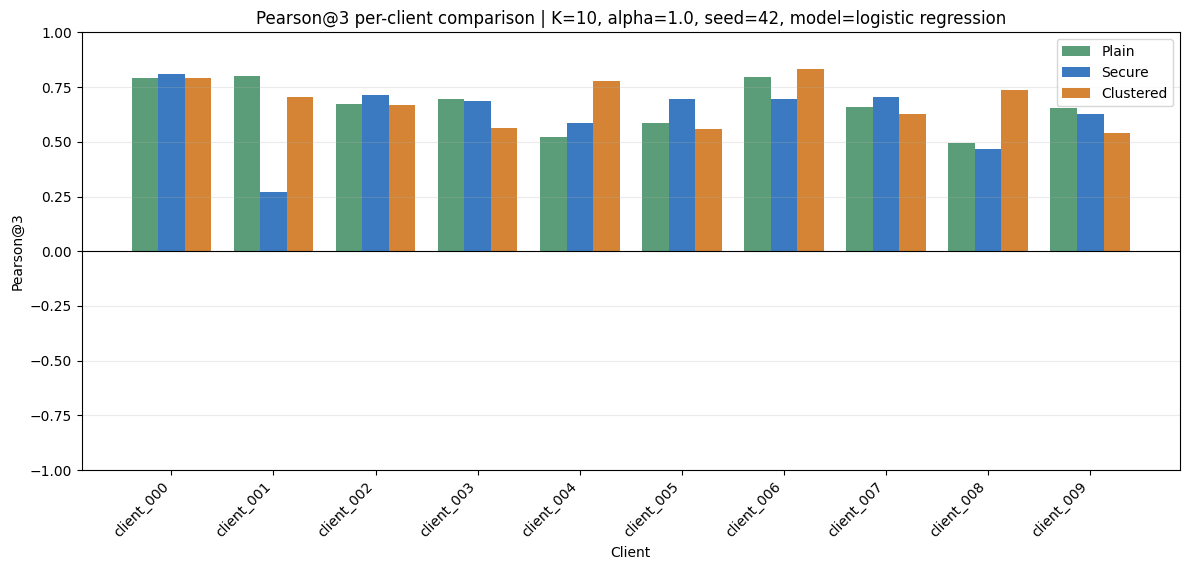

### Pearson@5

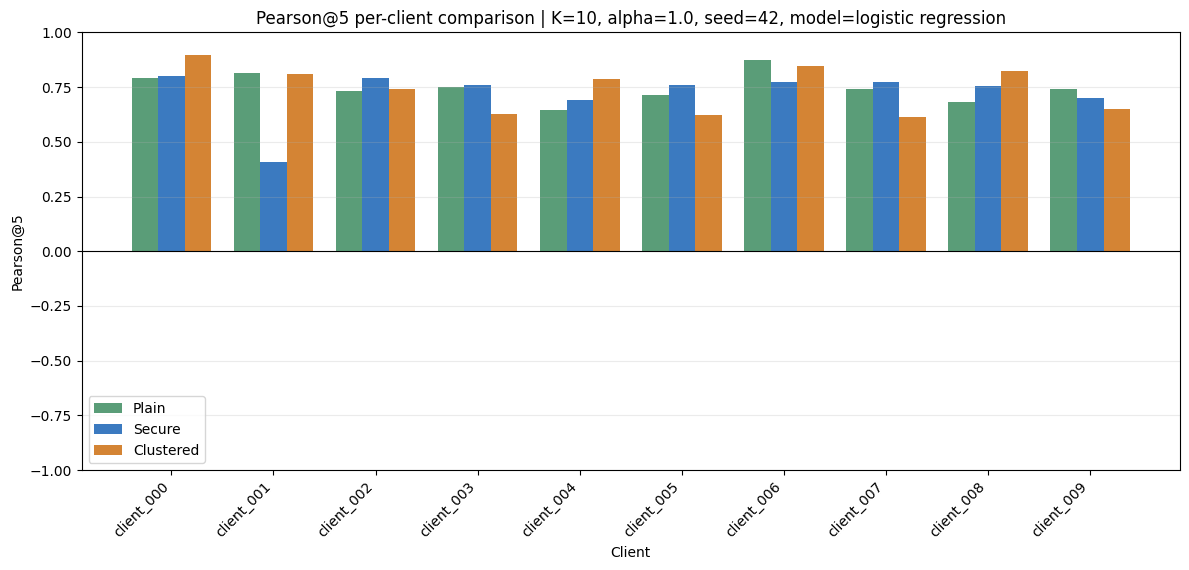

### Pearson@8

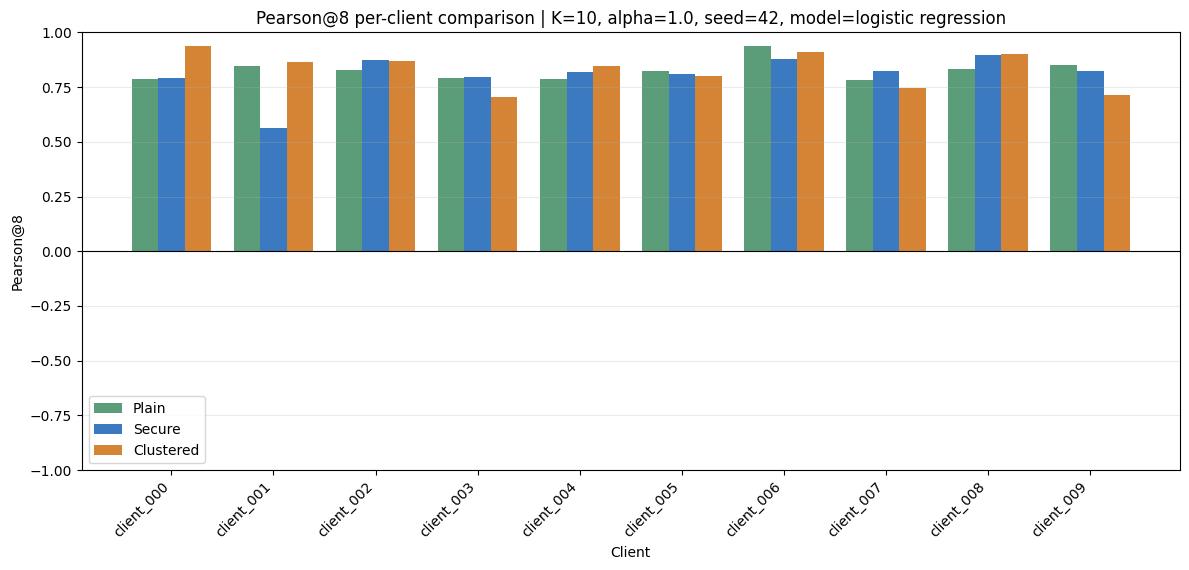

### Average Pearson@3, Pearson@5, and Pearson@8

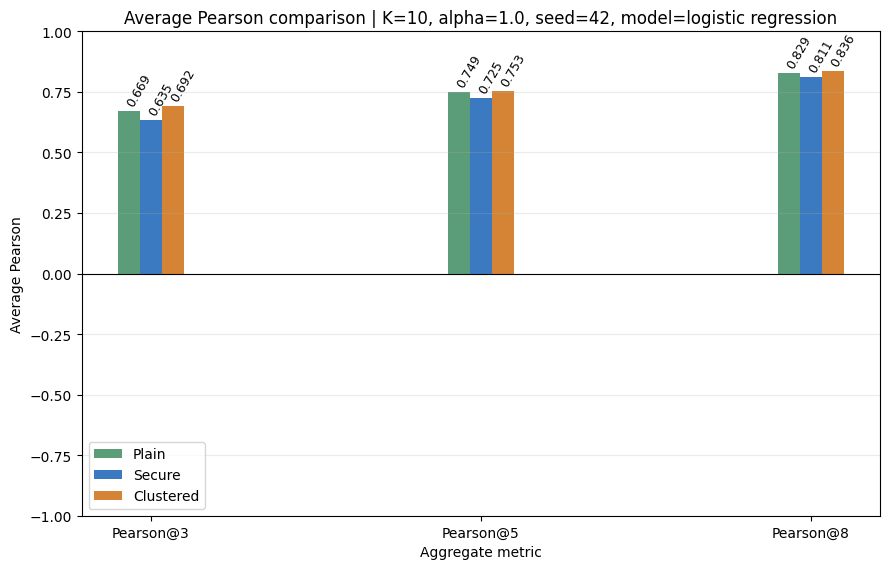

### Persona Assignment Diagnostics

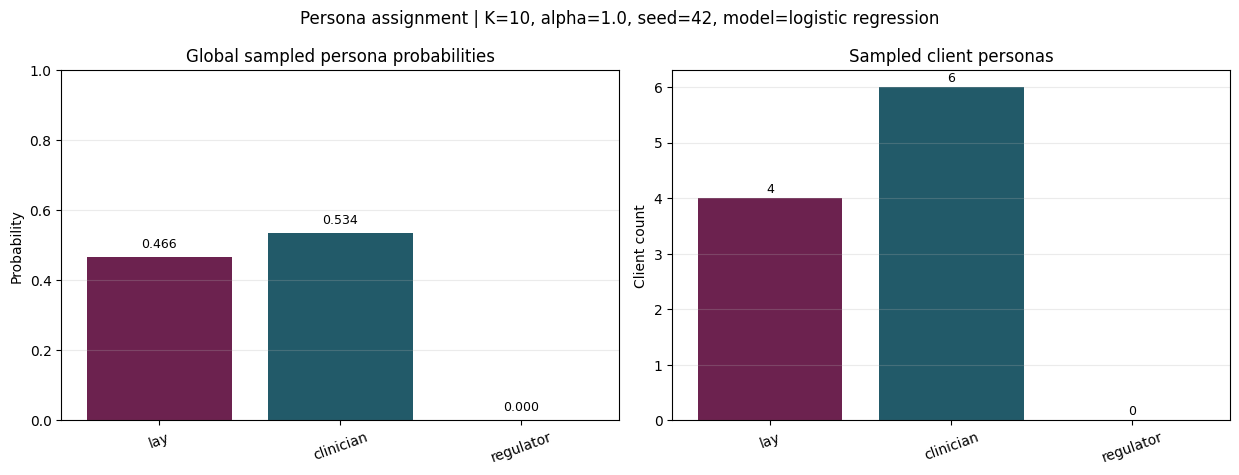

,client_id,persona,argmax_persona
0,client_000,lay,clinician
1,client_001,clinician,clinician
2,client_002,clinician,clinician
3,client_003,clinician,clinician
4,client_004,lay,clinician
5,client_005,lay,clinician
6,client_006,lay,clinician
7,client_007,clinician,clinician
8,client_008,clinician,clinician
9,client_009,clinician,clinician


### Cluster Alignment Diagnostics

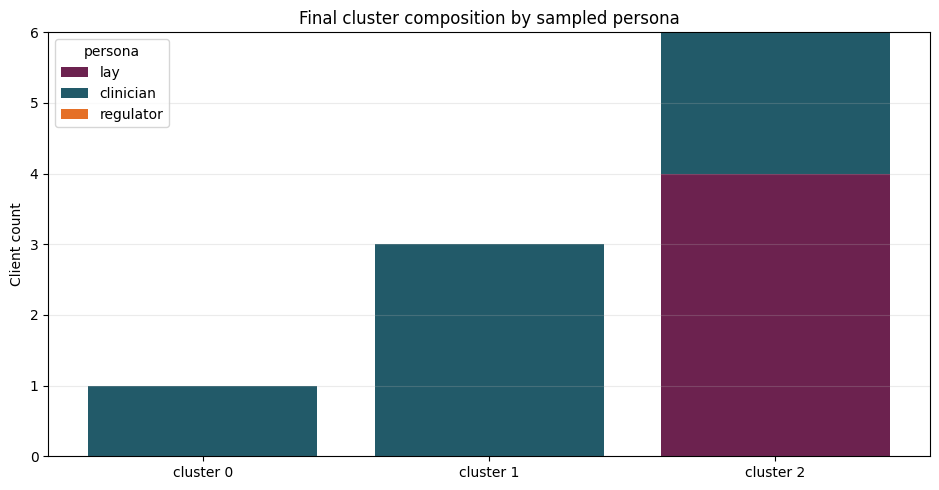

#### Persona-by-cluster contingency table

cluster_id,0,1,2
persona,,,
lay,0,0,4
clinician,1,3,2
regulator,0,0,0


#### Client-level sampled persona and final cluster assignment

,client_id,persona,argmax_persona,cluster_id
0,client_000,lay,clinician,2
1,client_001,clinician,clinician,1
2,client_002,clinician,clinician,1
3,client_003,clinician,clinician,1
4,client_004,lay,clinician,2
5,client_005,lay,clinician,2
6,client_006,lay,clinician,2
7,client_007,clinician,clinician,2
8,client_008,clinician,clinician,2
9,client_009,clinician,clinician,0


## K=10, alpha=0.3, seed=42, model=logistic regression

`run_id = federated-training-adult_income-20260426t223642651433+0000-logistic_regression-10clients-alpha0.3-seed42-e8df09baaba3`

### Pearson@3

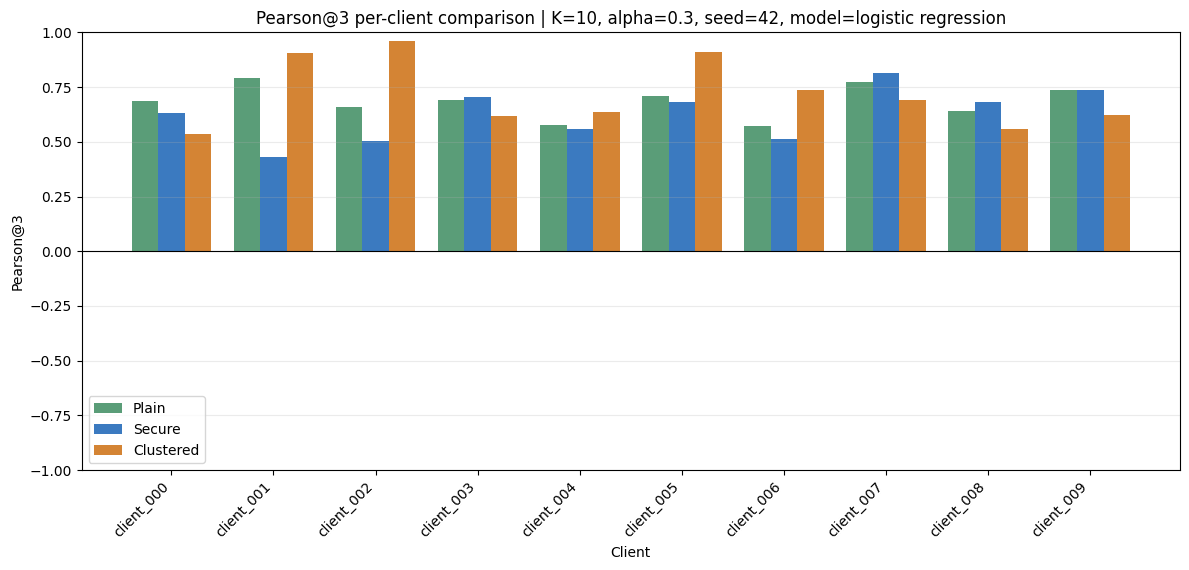

### Pearson@5

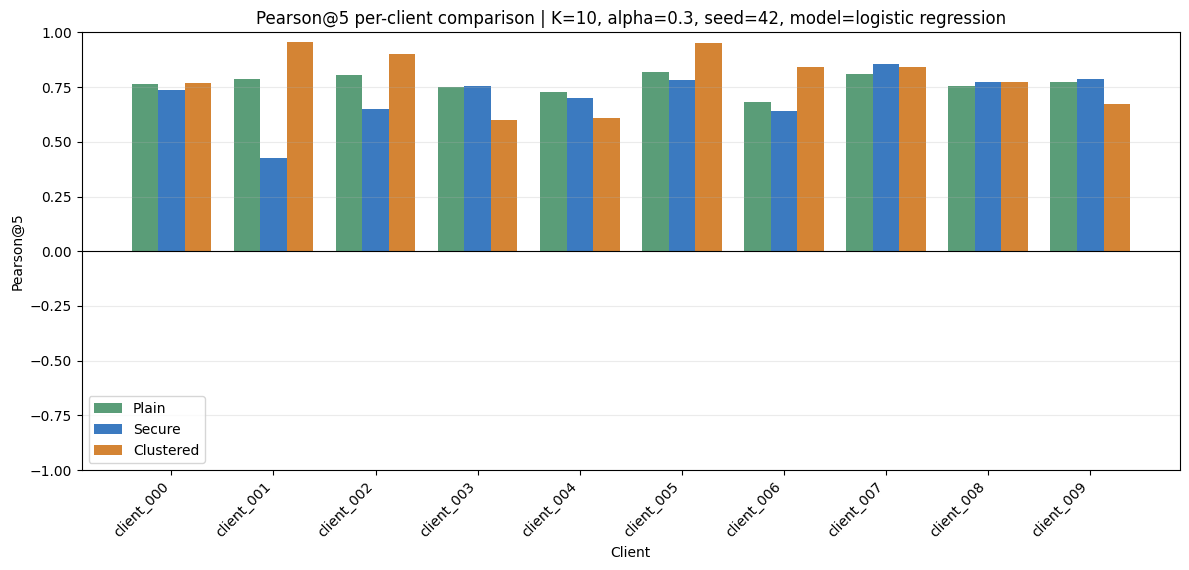

### Pearson@8

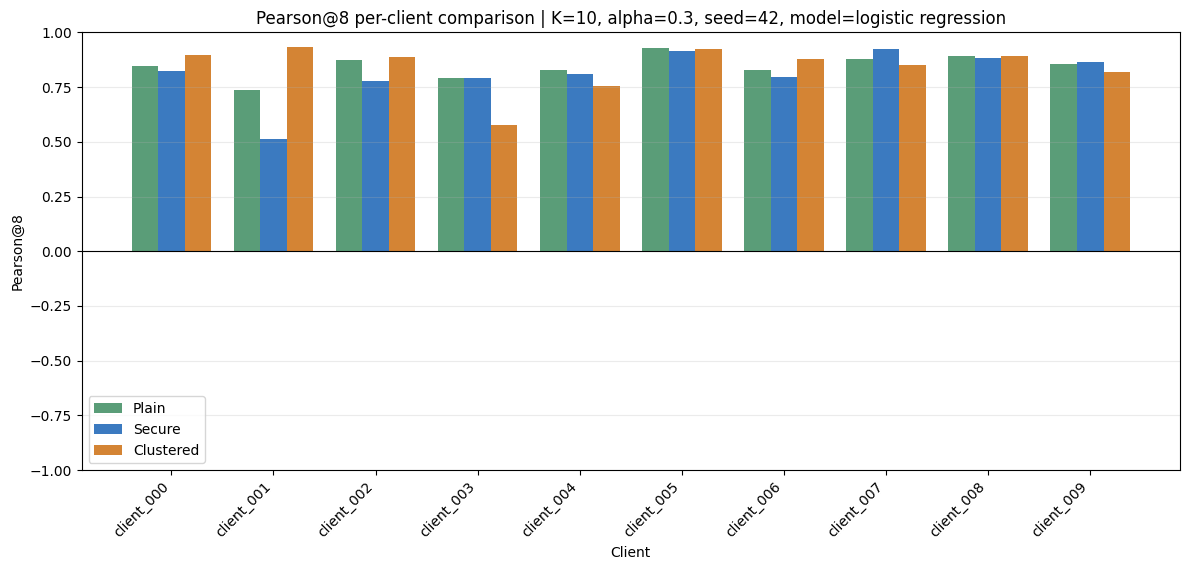

### Average Pearson@3, Pearson@5, and Pearson@8

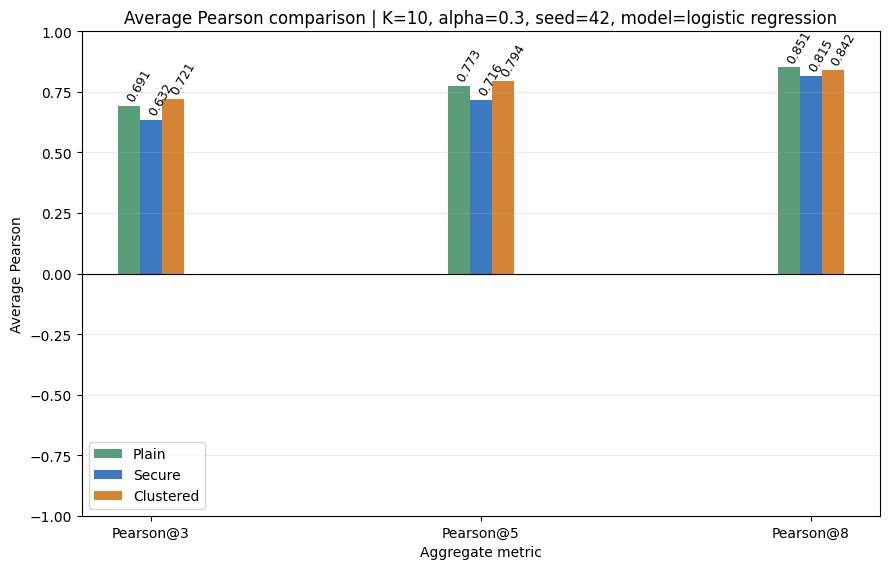

### Persona Assignment Diagnostics

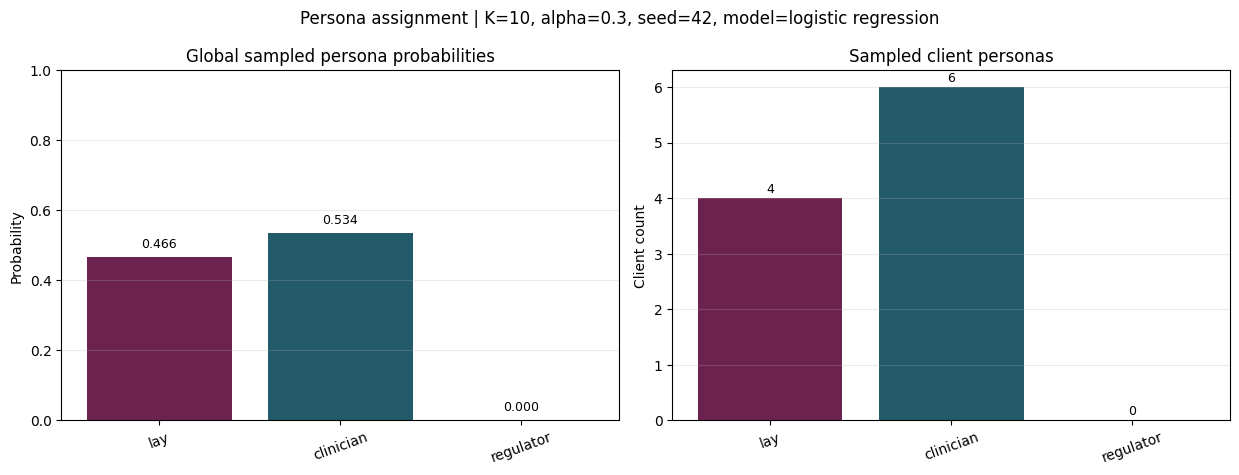

,client_id,persona,argmax_persona
0,client_000,lay,clinician
1,client_001,clinician,clinician
2,client_002,clinician,clinician
3,client_003,clinician,clinician
4,client_004,lay,clinician
5,client_005,lay,clinician
6,client_006,lay,clinician
7,client_007,clinician,clinician
8,client_008,clinician,clinician
9,client_009,clinician,clinician


### Cluster Alignment Diagnostics

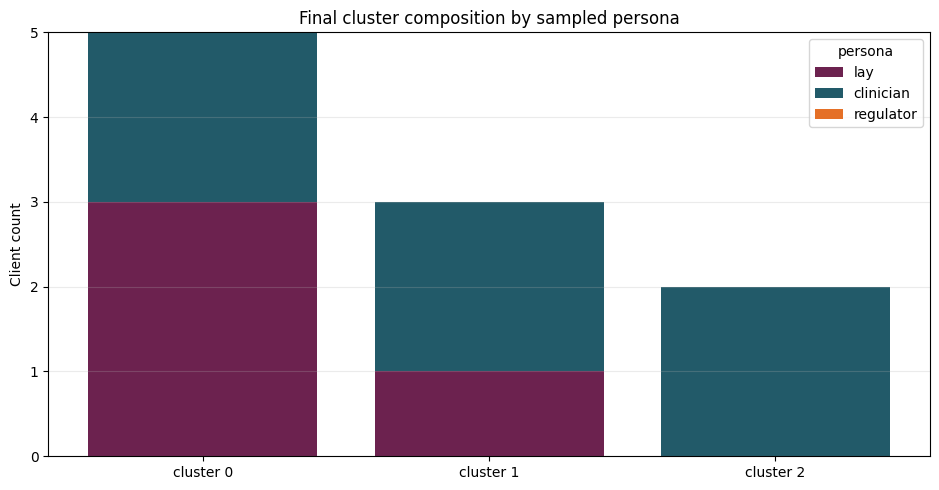

#### Persona-by-cluster contingency table

cluster_id,0,1,2
persona,,,
lay,3,1,0
clinician,2,2,2
regulator,0,0,0


#### Client-level sampled persona and final cluster assignment

,client_id,persona,argmax_persona,cluster_id
0,client_000,lay,clinician,0
1,client_001,clinician,clinician,2
2,client_002,clinician,clinician,0
3,client_003,clinician,clinician,0
4,client_004,lay,clinician,1
5,client_005,lay,clinician,0
6,client_006,lay,clinician,0
7,client_007,clinician,clinician,1
8,client_008,clinician,clinician,1
9,client_009,clinician,clinician,2


## K=15, alpha=0.3, seed=42, model=logistic regression

`run_id = federated-training-adult_income-20260427t063710289874+0000-logistic_regression-15clients-alpha0.3-seed42-536f2cd41ed2`

### Pearson@3

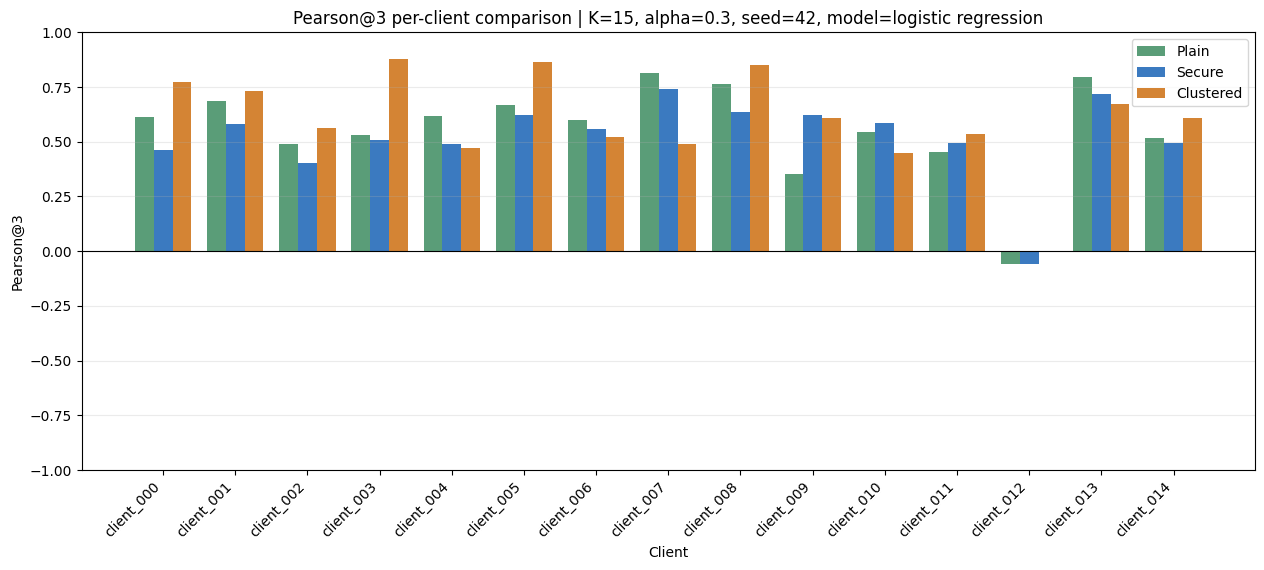

### Pearson@5

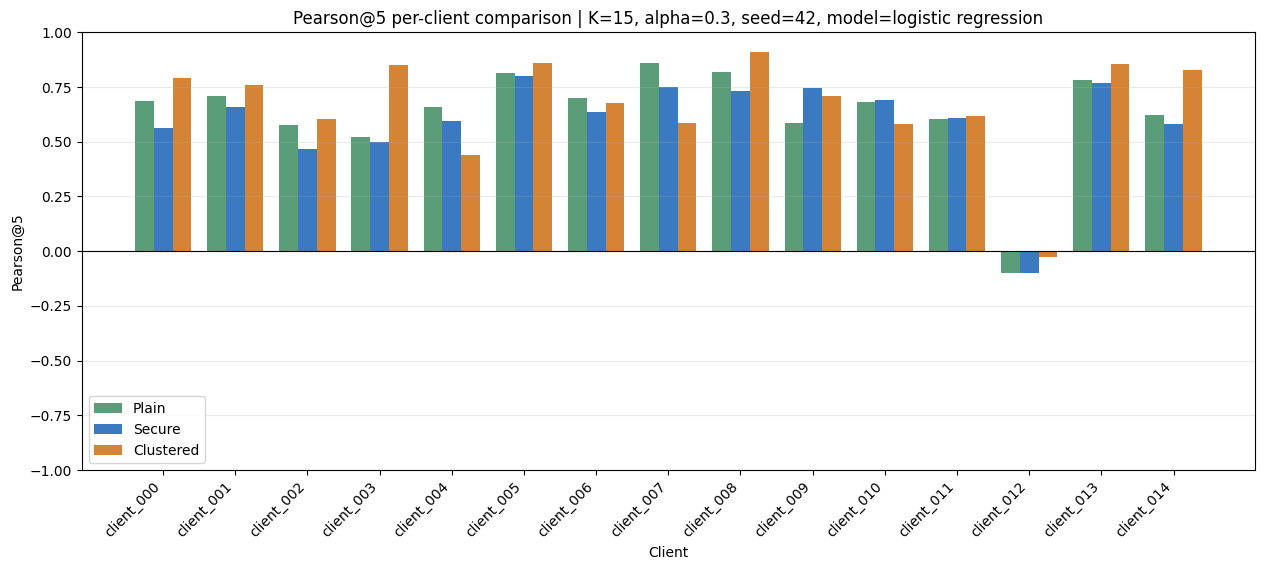

### Pearson@8

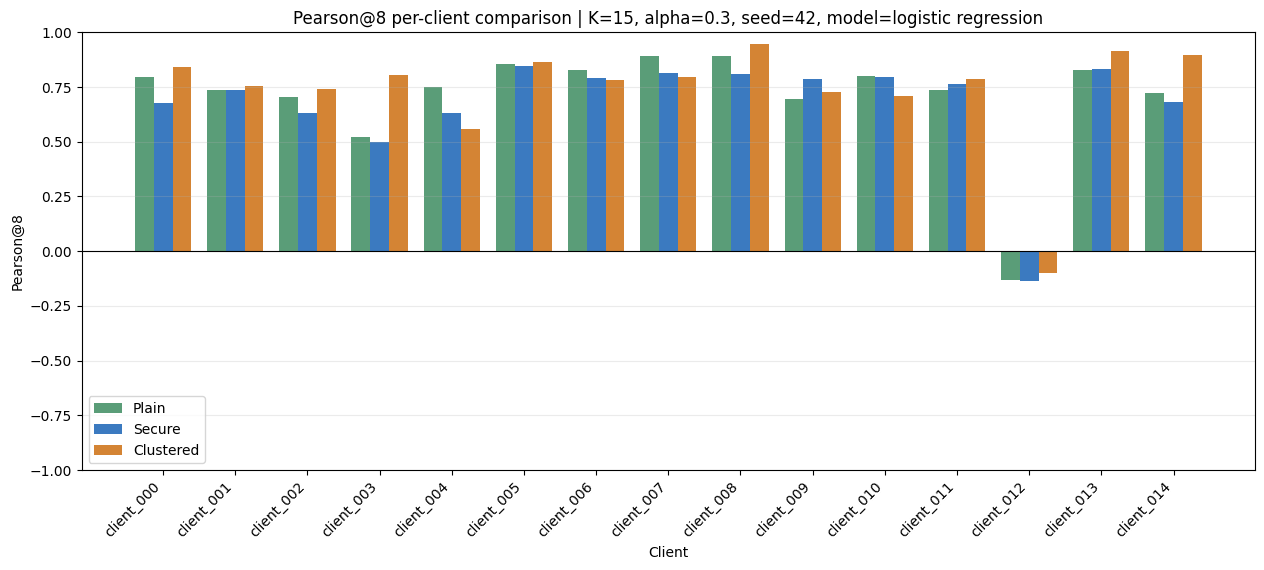

### Average Pearson@3, Pearson@5, and Pearson@8

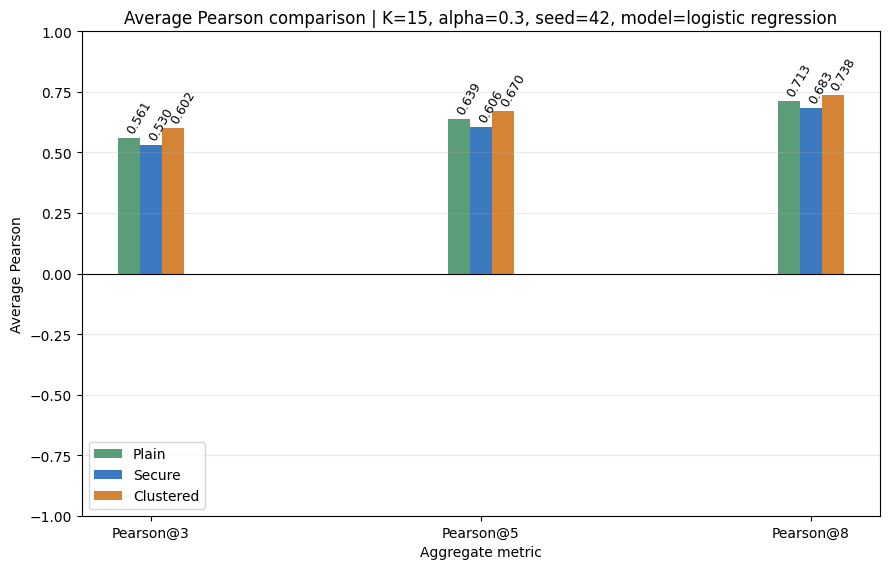

### Persona Assignment Diagnostics

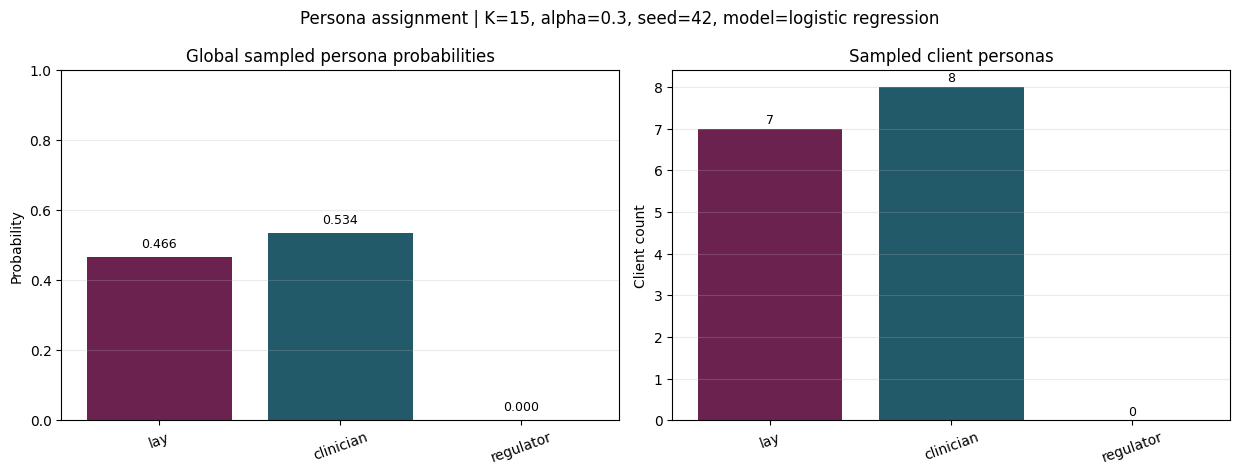

,client_id,persona,argmax_persona
0,client_000,lay,clinician
1,client_001,clinician,clinician
2,client_002,clinician,clinician
3,client_003,clinician,clinician
4,client_004,lay,clinician
5,client_005,lay,clinician
6,client_006,lay,clinician
7,client_007,clinician,clinician
8,client_008,clinician,clinician
9,client_009,clinician,clinician


### Cluster Alignment Diagnostics

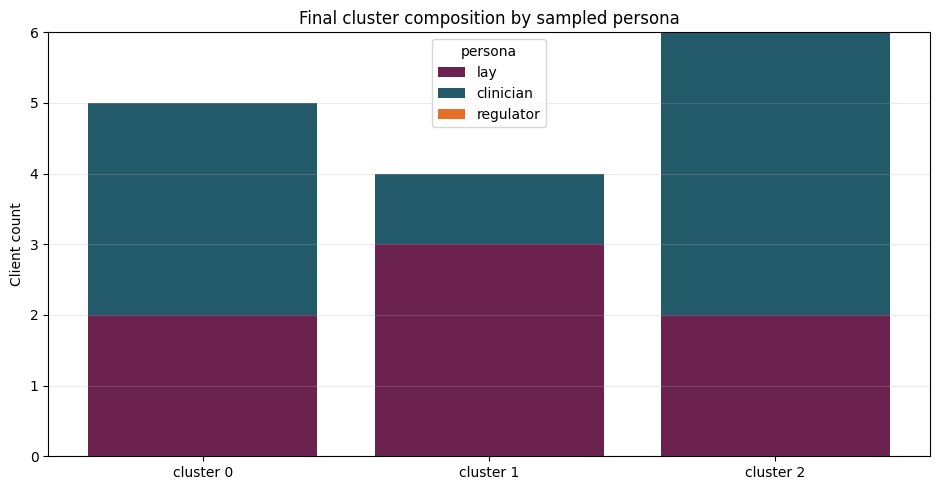

#### Persona-by-cluster contingency table

cluster_id,0,1,2
persona,,,
lay,2,3,2
clinician,3,1,4
regulator,0,0,0


#### Client-level sampled persona and final cluster assignment

,client_id,persona,argmax_persona,cluster_id
0,client_000,lay,clinician,2
1,client_001,clinician,clinician,0
2,client_002,clinician,clinician,1
3,client_003,clinician,clinician,2
4,client_004,lay,clinician,1
5,client_005,lay,clinician,0
6,client_006,lay,clinician,2
7,client_007,clinician,clinician,2
8,client_008,clinician,clinician,2
9,client_009,clinician,clinician,0


## K=5, alpha=0.1, seed=42, model=logistic regression

`run_id = federated-training-adult_income-20260503t135153628015+0000-logistic_regression-5clients-alpha0.1-seed42-c4ce0720be13`

### Pearson@3

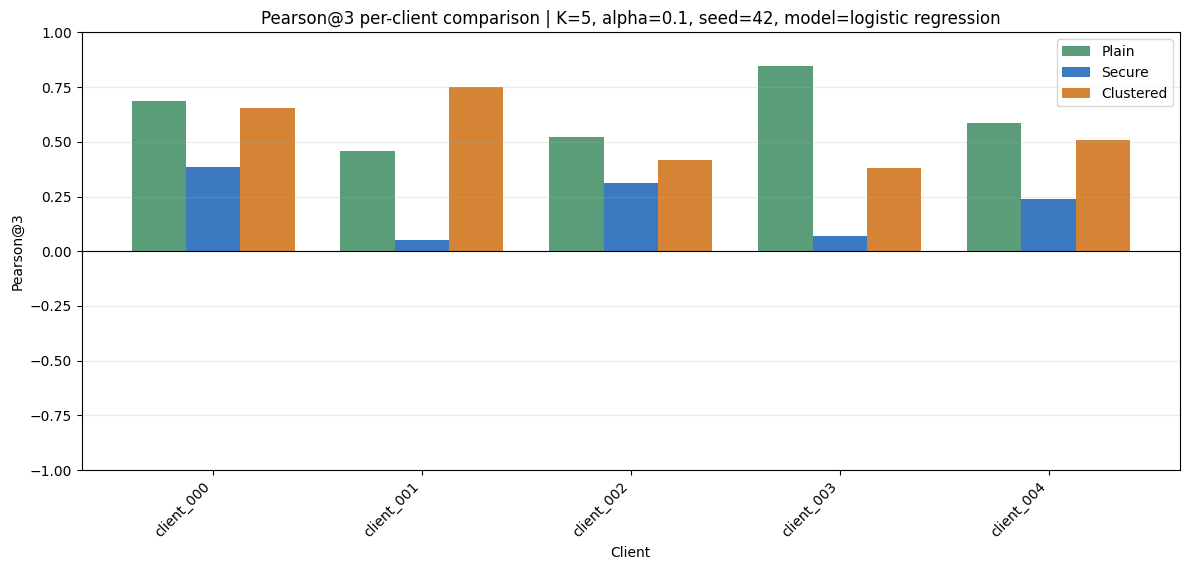

### Pearson@5

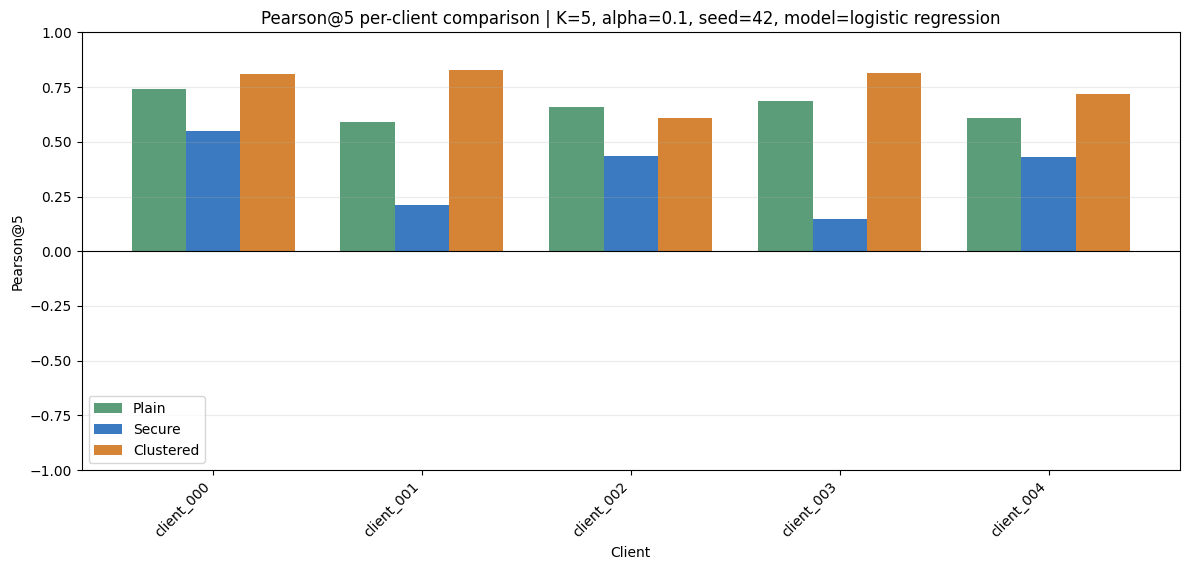

### Pearson@8

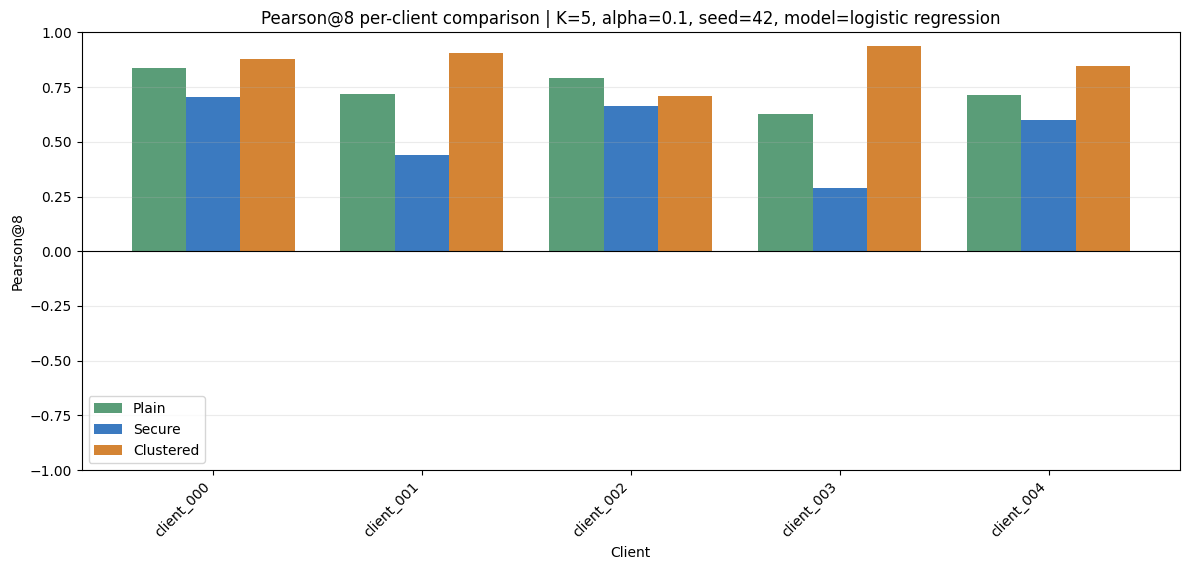

### Average Pearson@3, Pearson@5, and Pearson@8

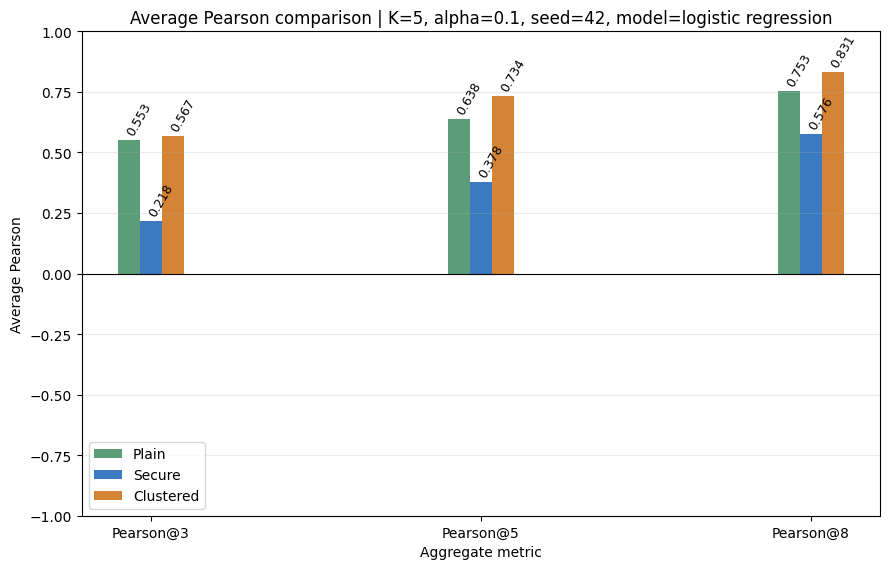

### Persona Assignment Diagnostics

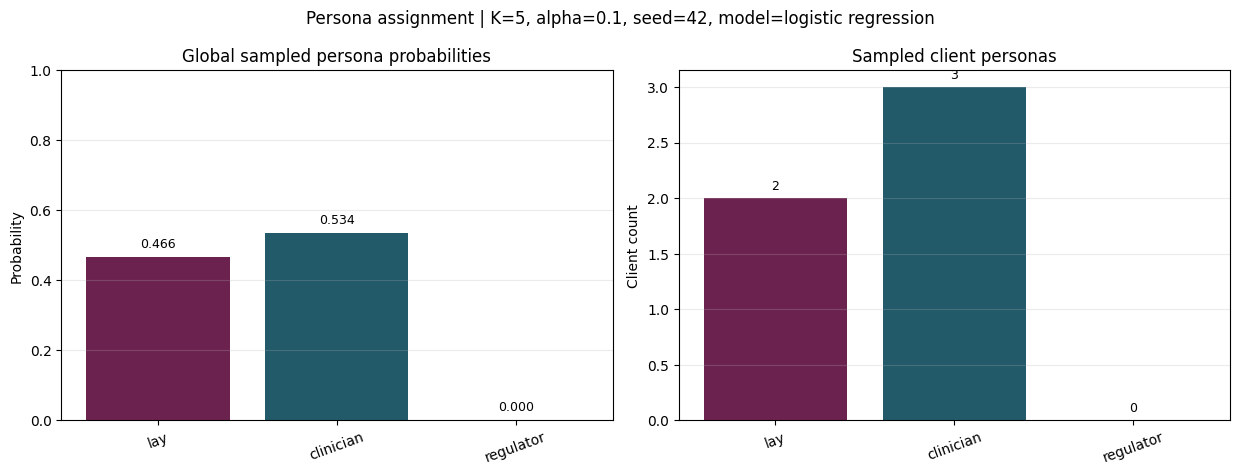

,client_id,persona,argmax_persona
0,client_000,lay,clinician
1,client_001,clinician,clinician
2,client_002,clinician,clinician
3,client_003,clinician,clinician
4,client_004,lay,clinician


### Cluster Alignment Diagnostics

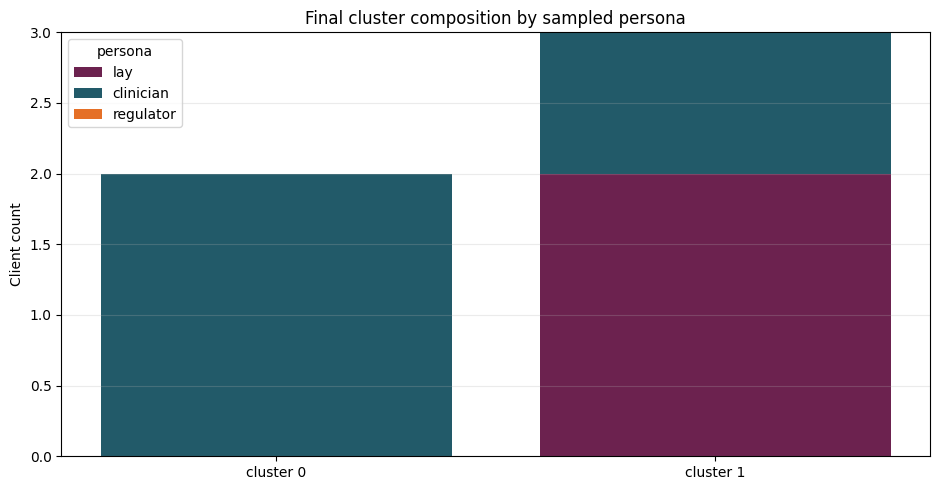

#### Persona-by-cluster contingency table

cluster_id,0,1
persona,,
lay,0,2
clinician,2,1
regulator,0,0


#### Client-level sampled persona and final cluster assignment

,client_id,persona,argmax_persona,cluster_id
0,client_000,lay,clinician,1
1,client_001,clinician,clinician,0
2,client_002,clinician,clinician,1
3,client_003,clinician,clinician,0
4,client_004,lay,clinician,1


## K=5, alpha=0.3, seed=42, model=logistic regression

`run_id = federated-training-adult_income-20260503t135226242826+0000-logistic_regression-5clients-alpha0.3-seed42-987d584d73df`

### Pearson@3

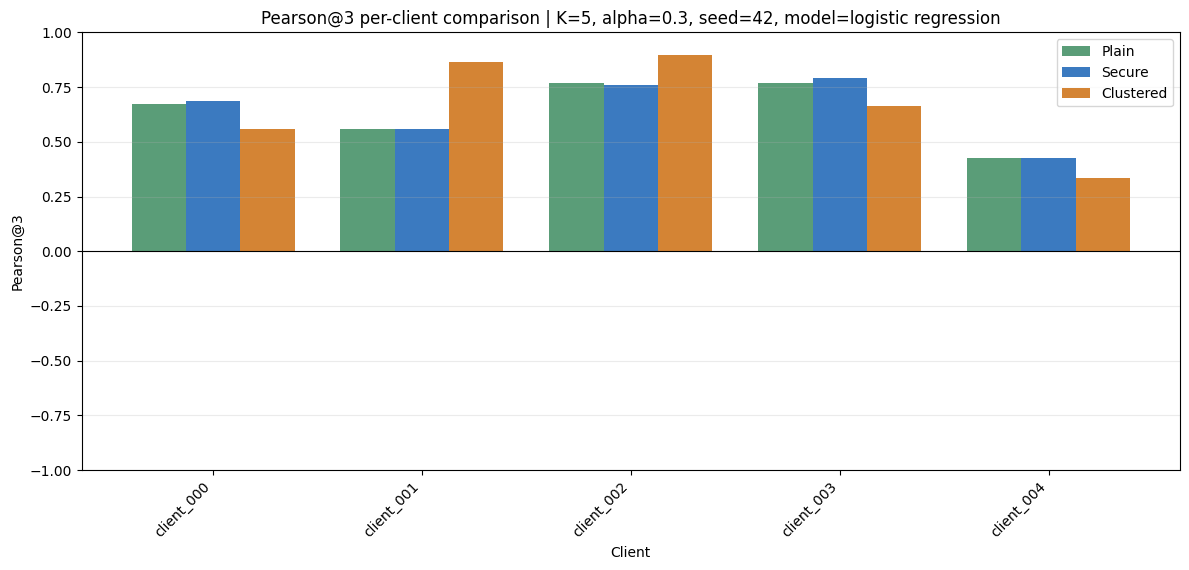

### Pearson@5

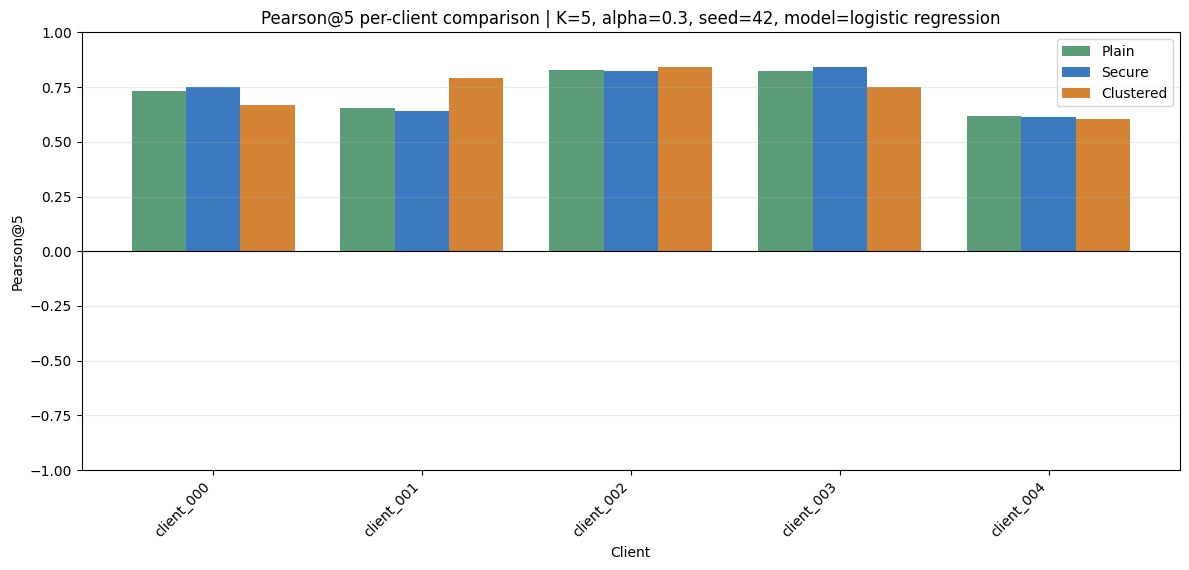

### Pearson@8

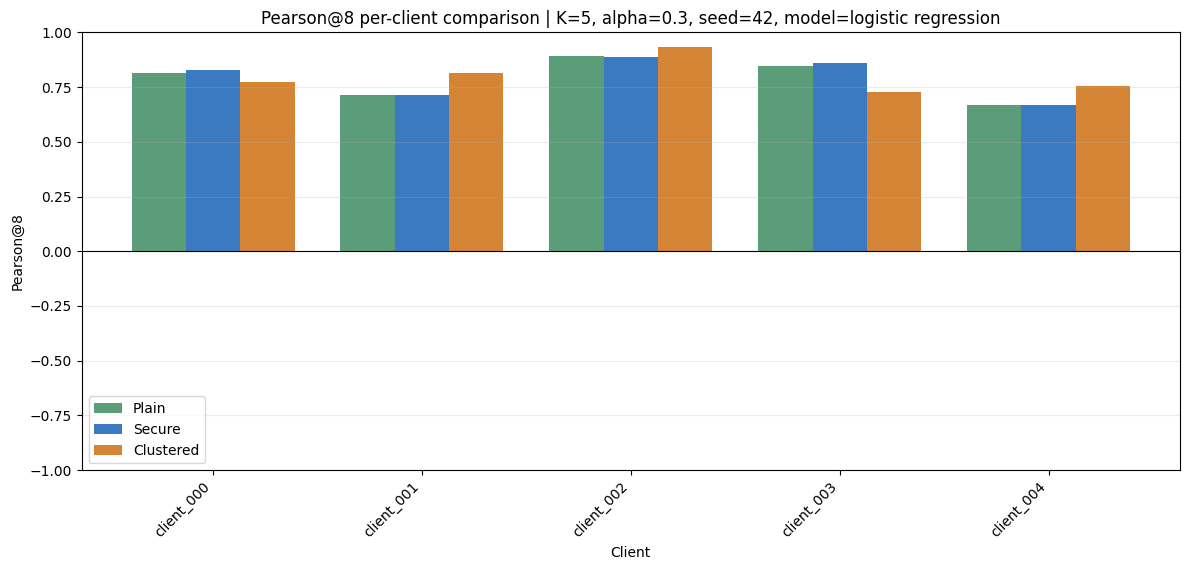

### Average Pearson@3, Pearson@5, and Pearson@8

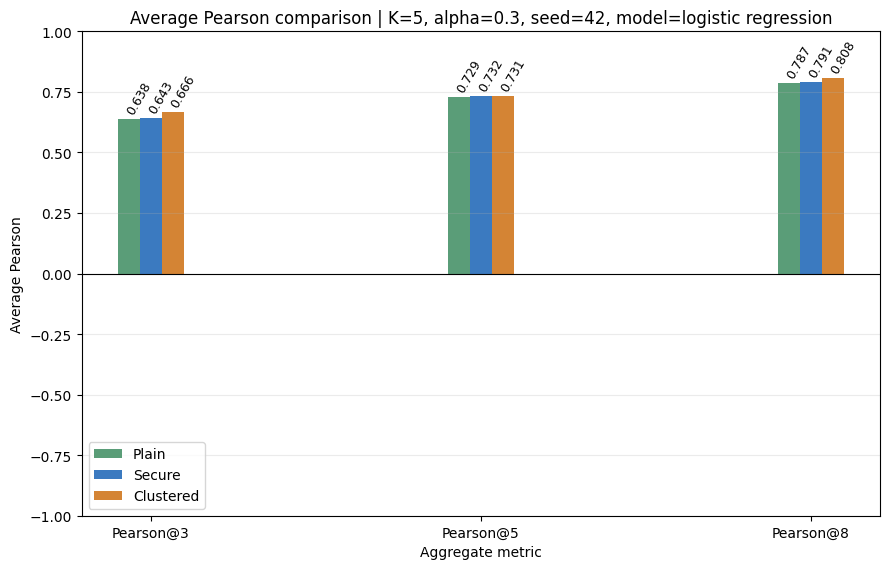

### Persona Assignment Diagnostics

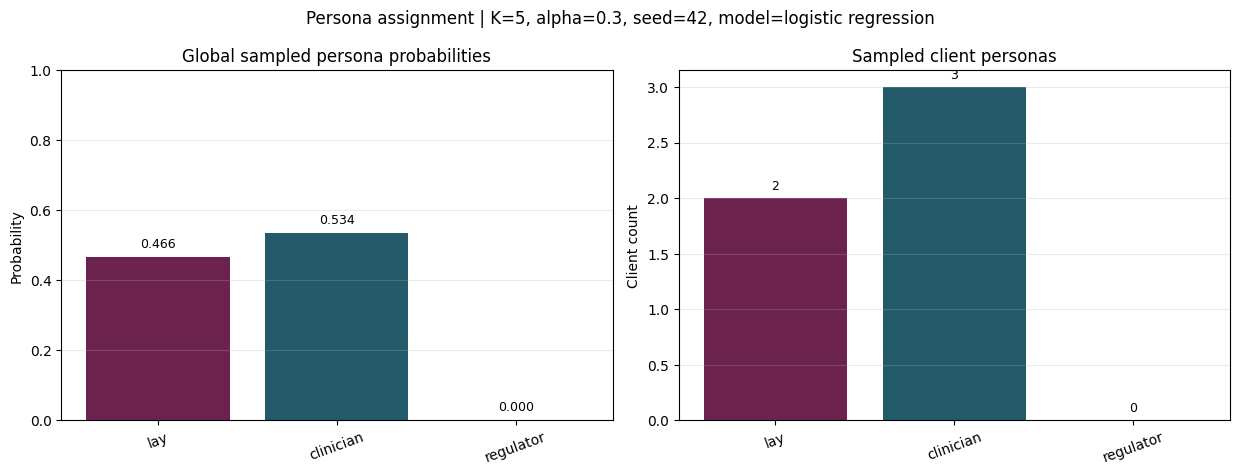

,client_id,persona,argmax_persona
0,client_000,lay,clinician
1,client_001,clinician,clinician
2,client_002,clinician,clinician
3,client_003,clinician,clinician
4,client_004,lay,clinician


### Cluster Alignment Diagnostics

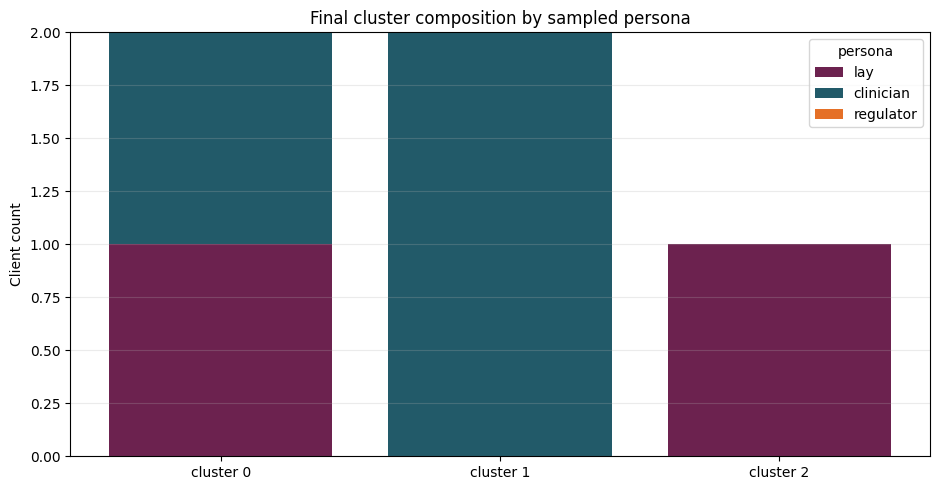

#### Persona-by-cluster contingency table

cluster_id,0,1,2
persona,,,
lay,1,0,1
clinician,1,2,0
regulator,0,0,0


#### Client-level sampled persona and final cluster assignment

,client_id,persona,argmax_persona,cluster_id
0,client_000,lay,clinician,2
1,client_001,clinician,clinician,1
2,client_002,clinician,clinician,0
3,client_003,clinician,clinician,1
4,client_004,lay,clinician,0


## K=5, alpha=1.0, seed=42, model=logistic regression

`run_id = federated-training-adult_income-20260503t135259866809+0000-logistic_regression-5clients-alpha1.0-seed42-2c46959e584f`

### Pearson@3

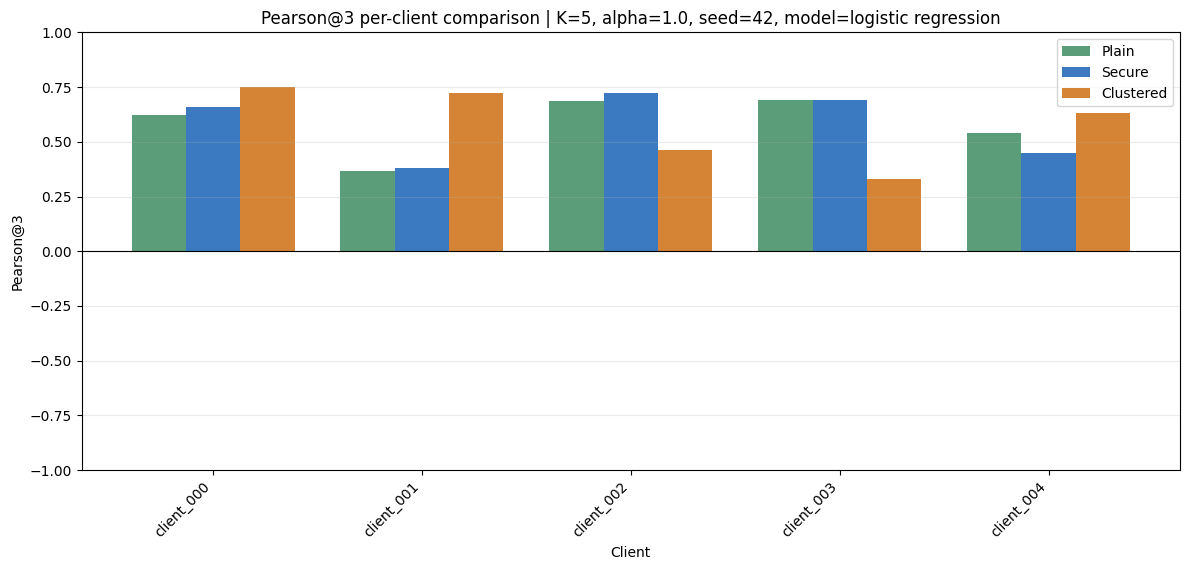

### Pearson@5

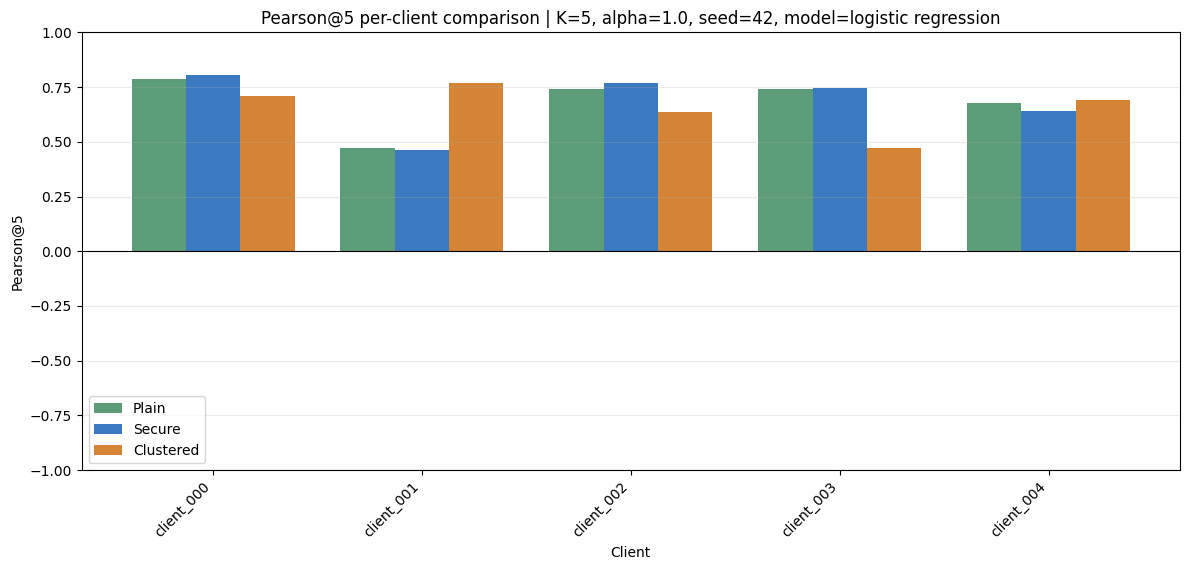

### Pearson@8

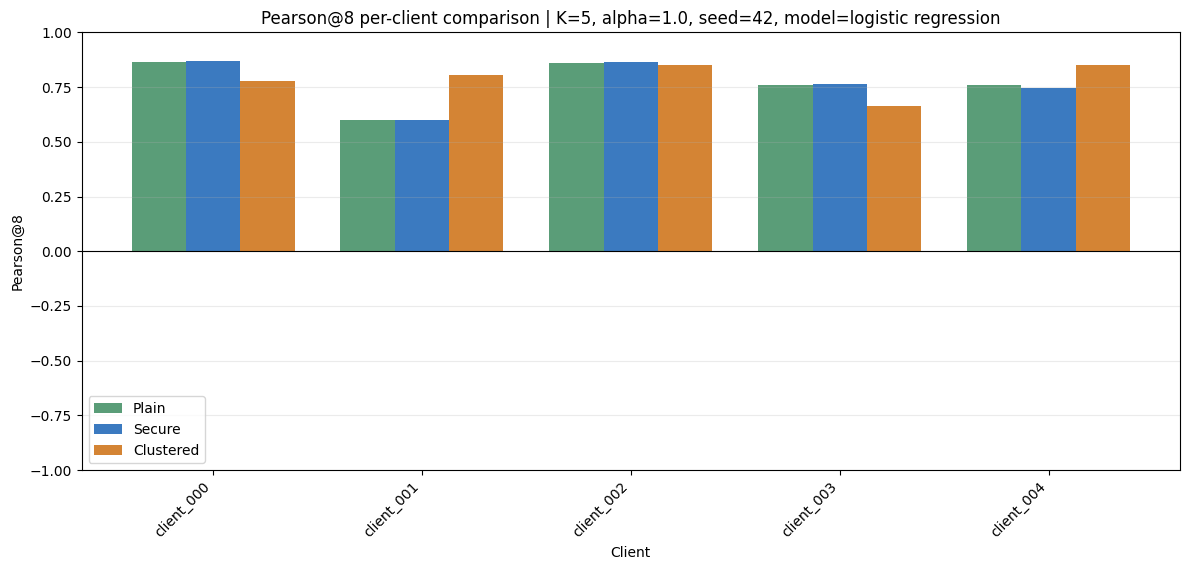

### Average Pearson@3, Pearson@5, and Pearson@8

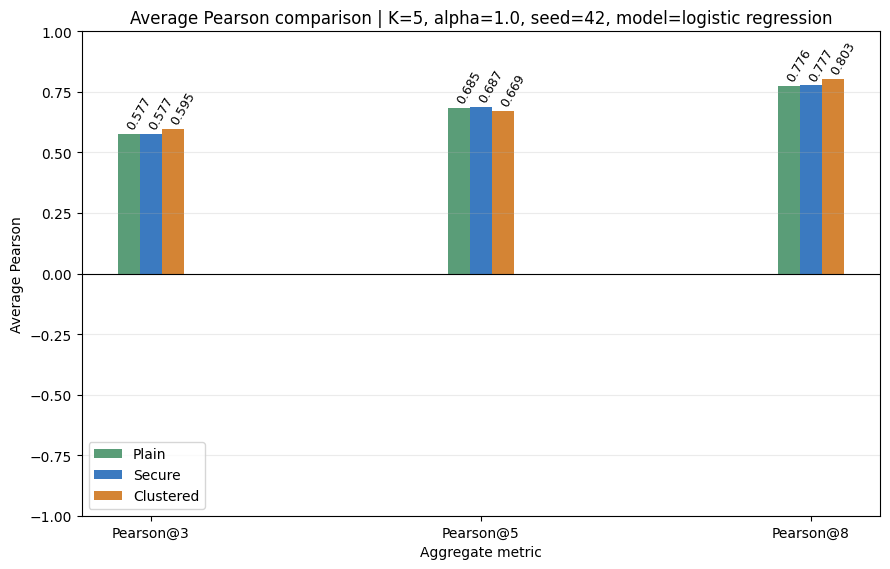

### Persona Assignment Diagnostics

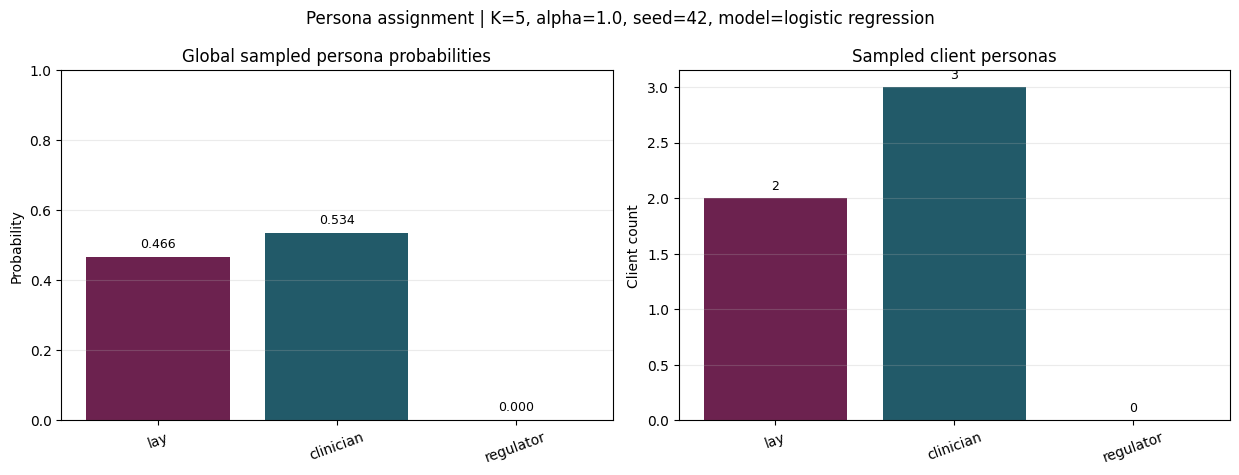

,client_id,persona,argmax_persona
0,client_000,lay,clinician
1,client_001,clinician,clinician
2,client_002,clinician,clinician
3,client_003,clinician,clinician
4,client_004,lay,clinician


### Cluster Alignment Diagnostics

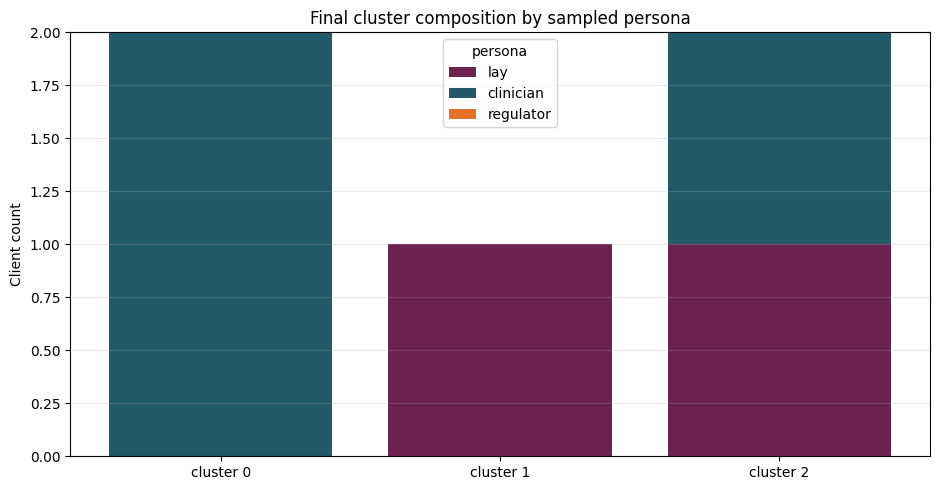

#### Persona-by-cluster contingency table

cluster_id,0,1,2
persona,,,
lay,0,1,1
clinician,2,0,1
regulator,0,0,0


#### Client-level sampled persona and final cluster assignment

,client_id,persona,argmax_persona,cluster_id
0,client_000,lay,clinician,1
1,client_001,clinician,clinician,0
2,client_002,clinician,clinician,2
3,client_003,clinician,clinician,0
4,client_004,lay,clinician,2


## K=5, alpha=10.0, seed=42, model=logistic regression

`run_id = federated-training-adult_income-20260503t135335672402+0000-logistic_regression-5clients-alpha10.0-seed42-95917a12ac76`

### Pearson@3

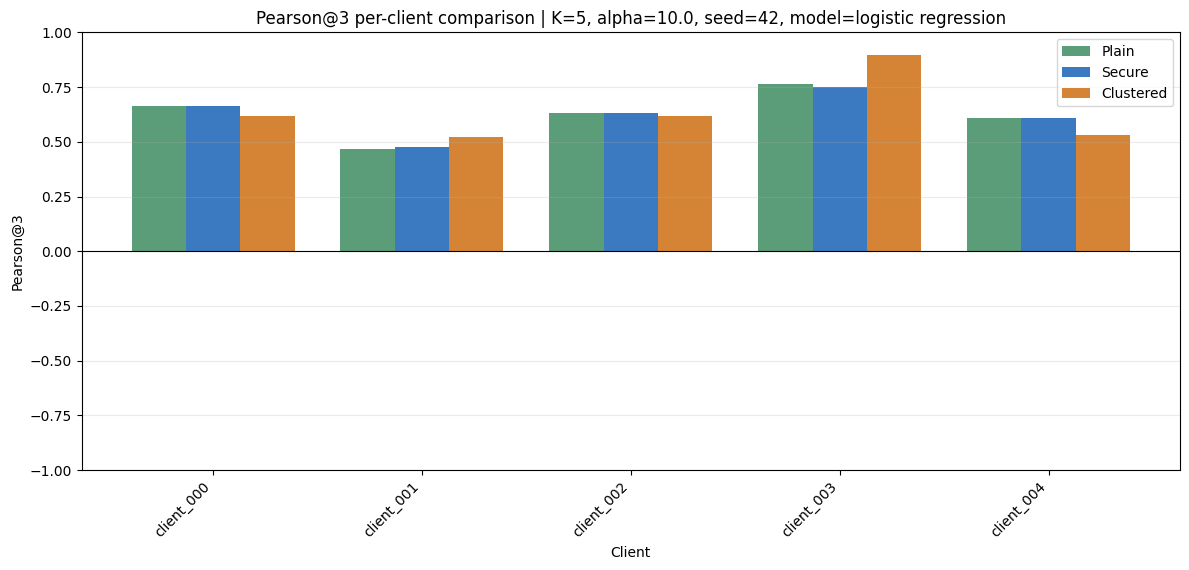

### Pearson@5

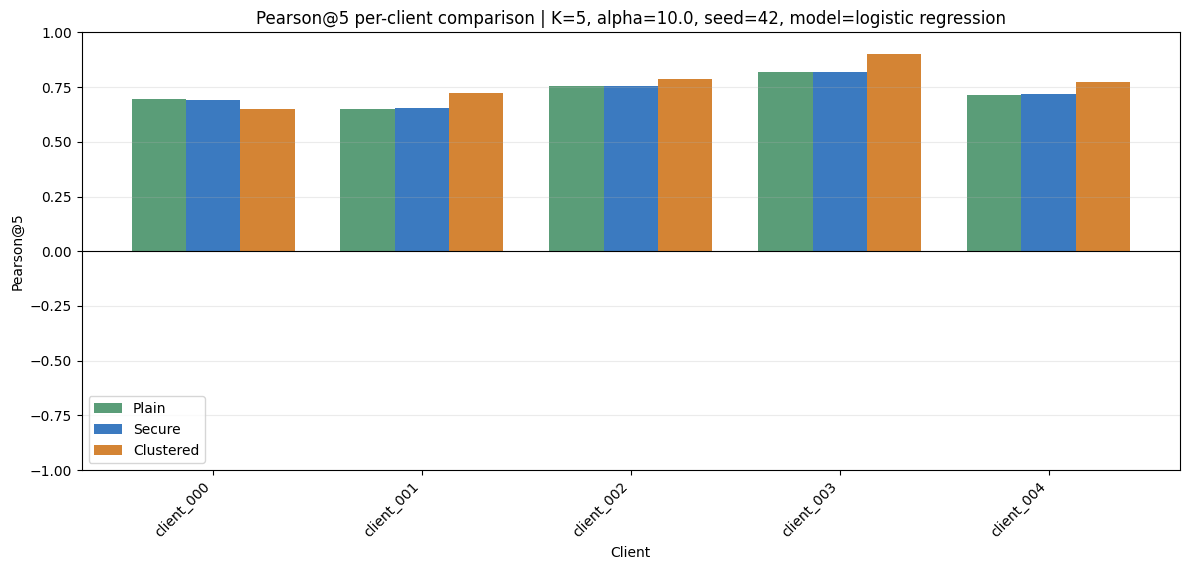

### Pearson@8

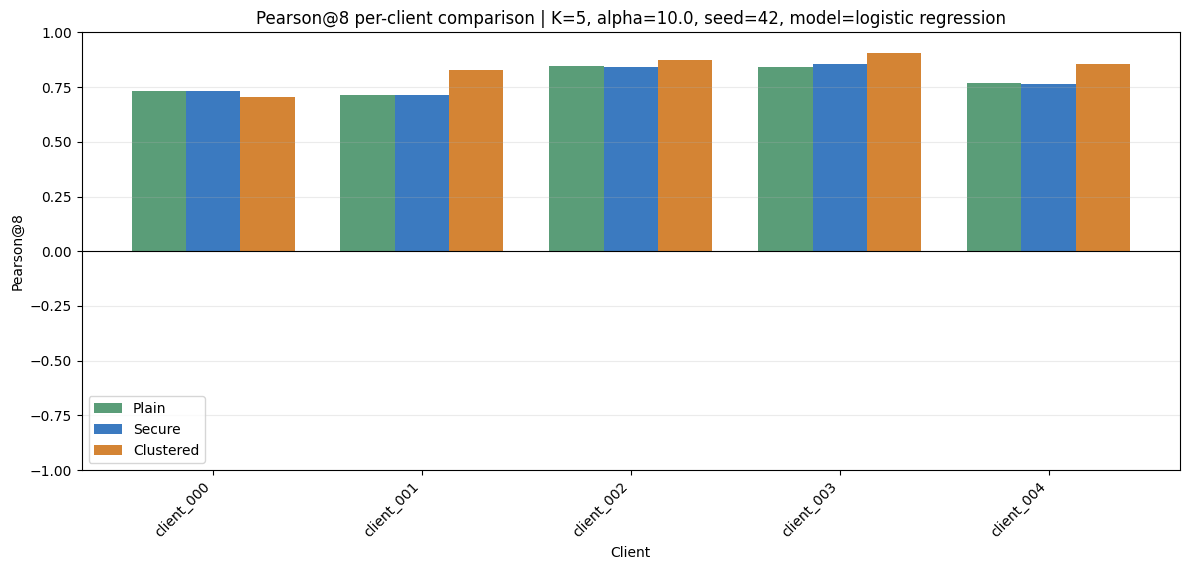

### Average Pearson@3, Pearson@5, and Pearson@8

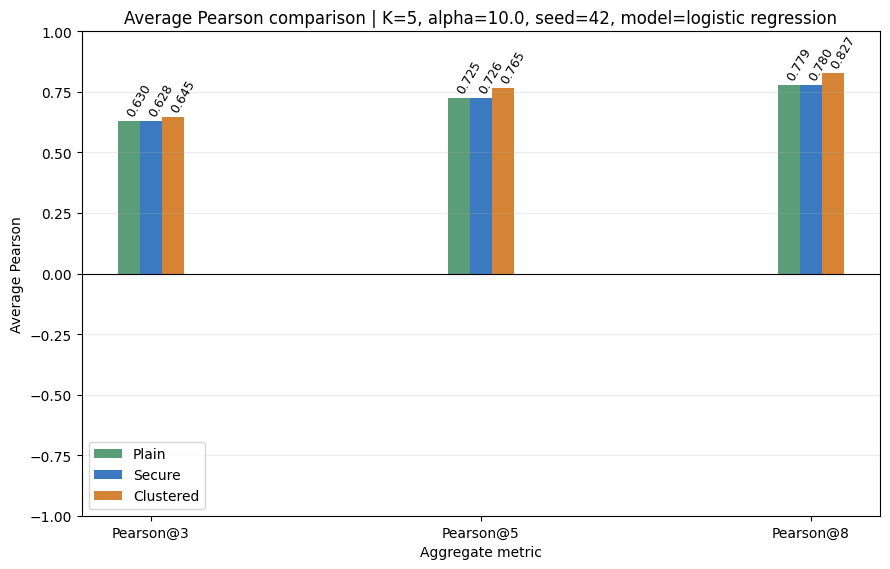

### Persona Assignment Diagnostics

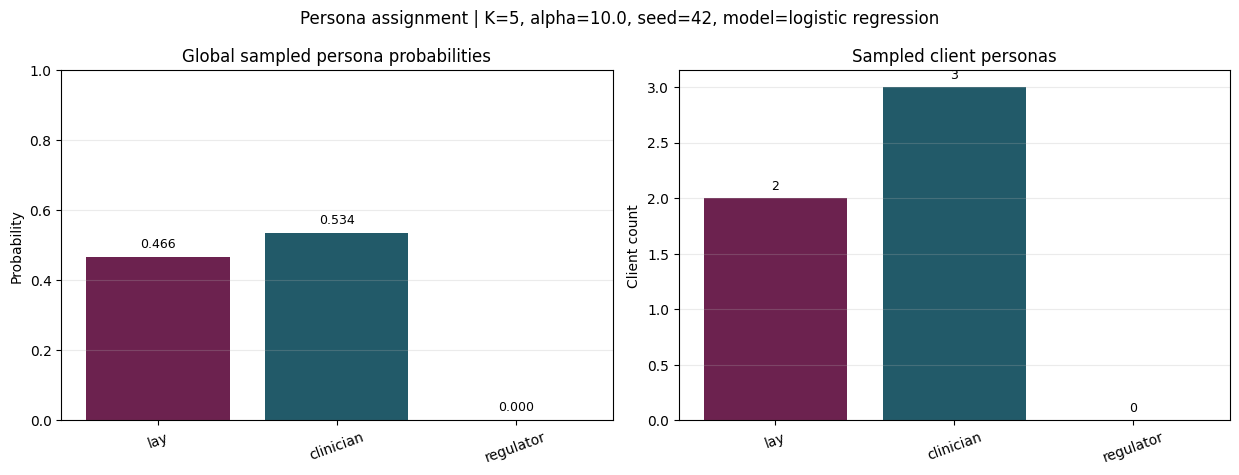

,client_id,persona,argmax_persona
0,client_000,lay,clinician
1,client_001,clinician,clinician
2,client_002,clinician,clinician
3,client_003,clinician,clinician
4,client_004,lay,clinician


### Cluster Alignment Diagnostics

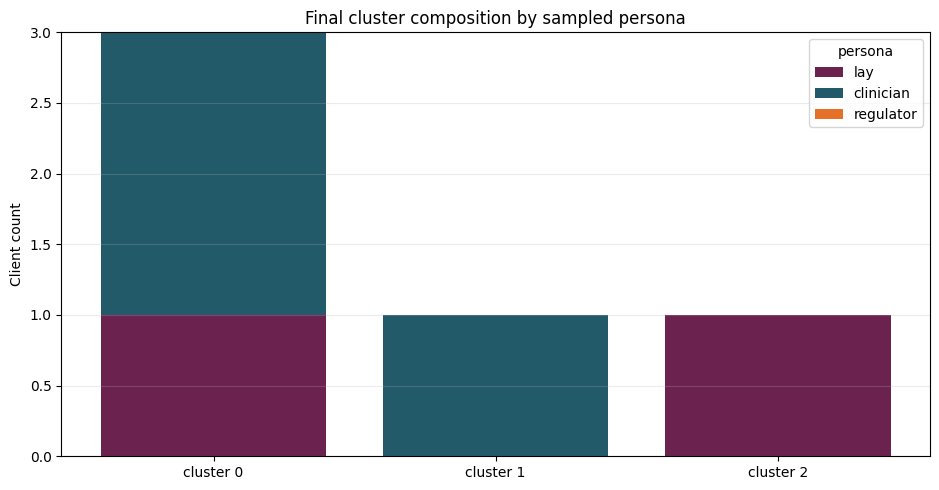

#### Persona-by-cluster contingency table

cluster_id,0,1,2
persona,,,
lay,1,0,1
clinician,2,1,0
regulator,0,0,0


#### Client-level sampled persona and final cluster assignment

,client_id,persona,argmax_persona,cluster_id
0,client_000,lay,clinician,2
1,client_001,clinician,clinician,0
2,client_002,clinician,clinician,0
3,client_003,clinician,clinician,1
4,client_004,lay,clinician,0


## K=10, alpha=0.1, seed=42, model=logistic regression

`run_id = federated-training-adult_income-20260503t135410435425+0000-logistic_regression-10clients-alpha0.1-seed42-5ab9379ae09e`

### Pearson@3

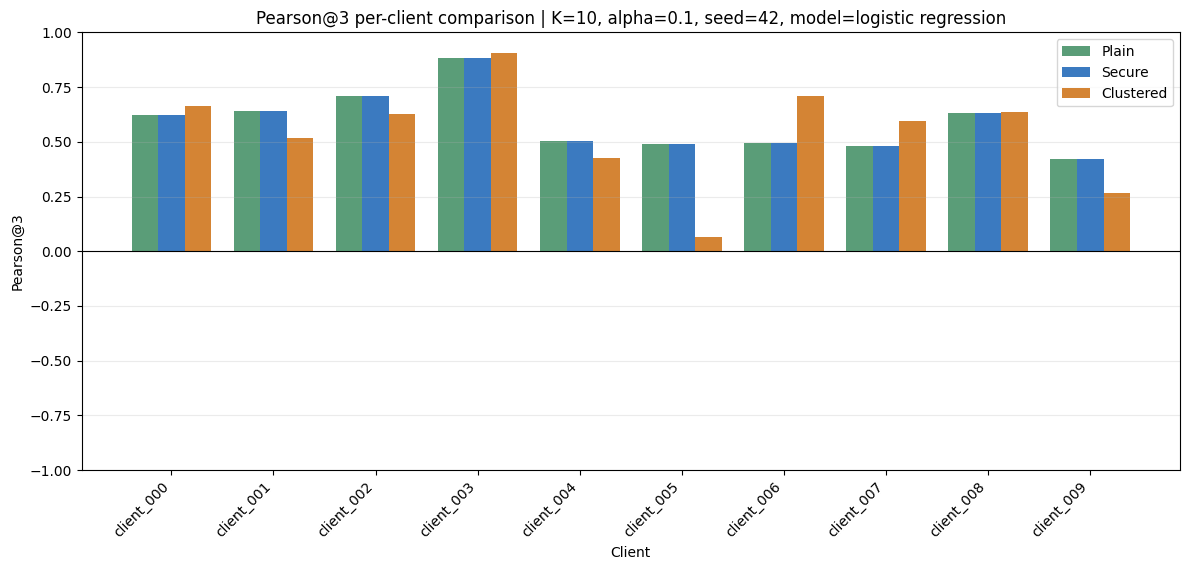

### Pearson@5

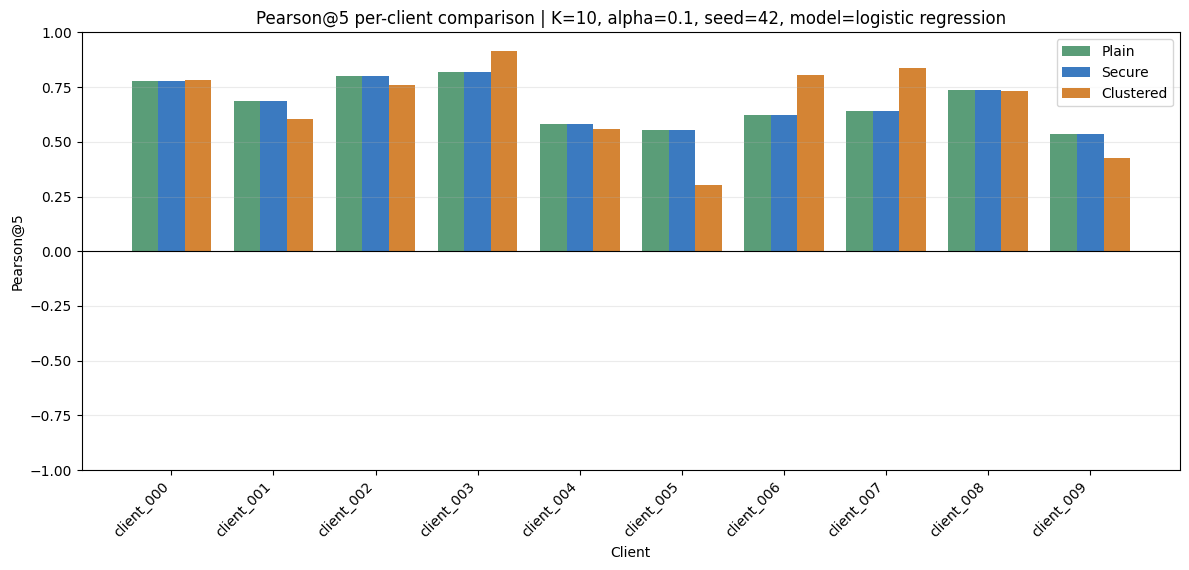

### Pearson@8

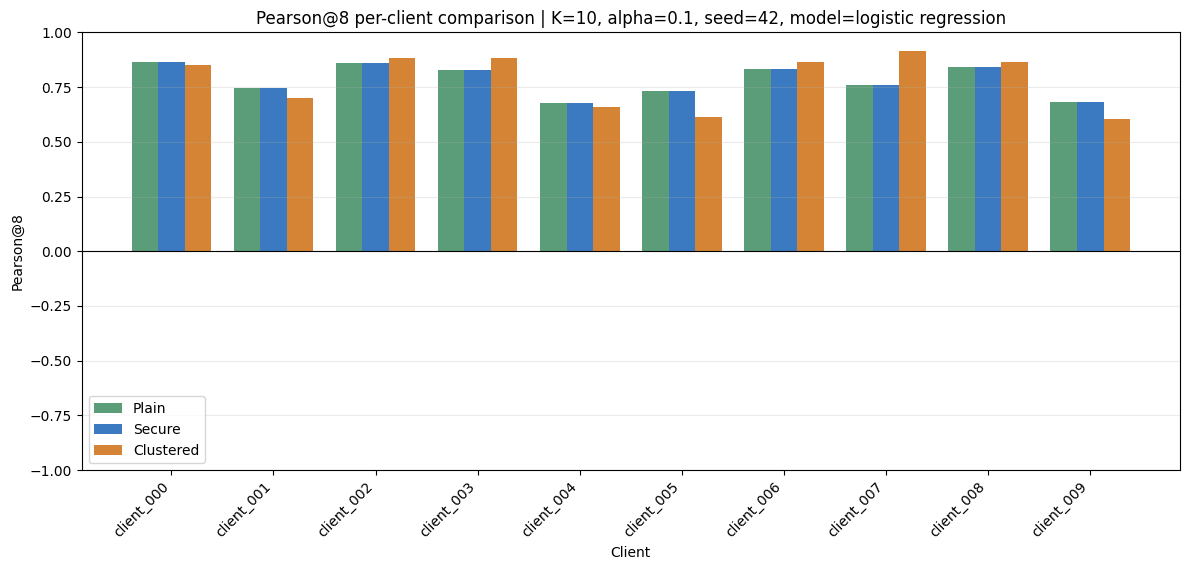

### Average Pearson@3, Pearson@5, and Pearson@8

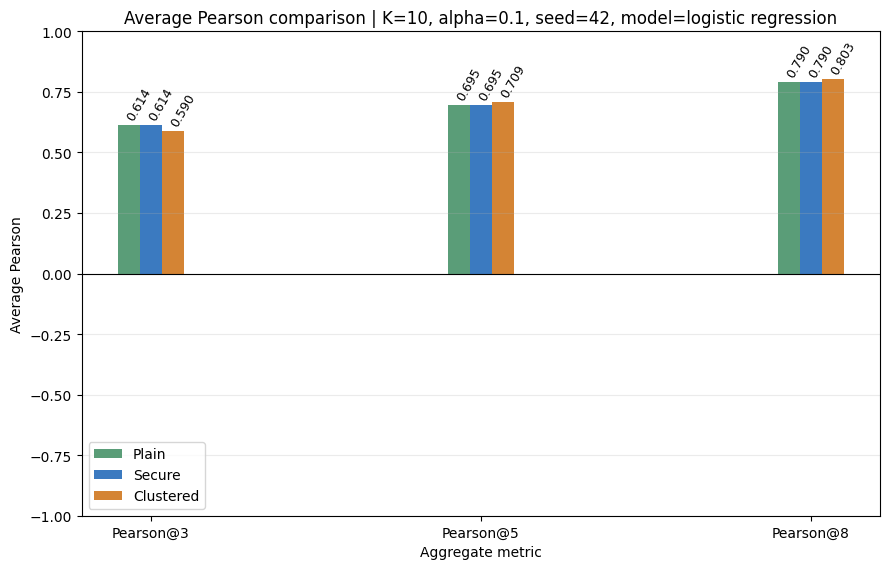

### Persona Assignment Diagnostics

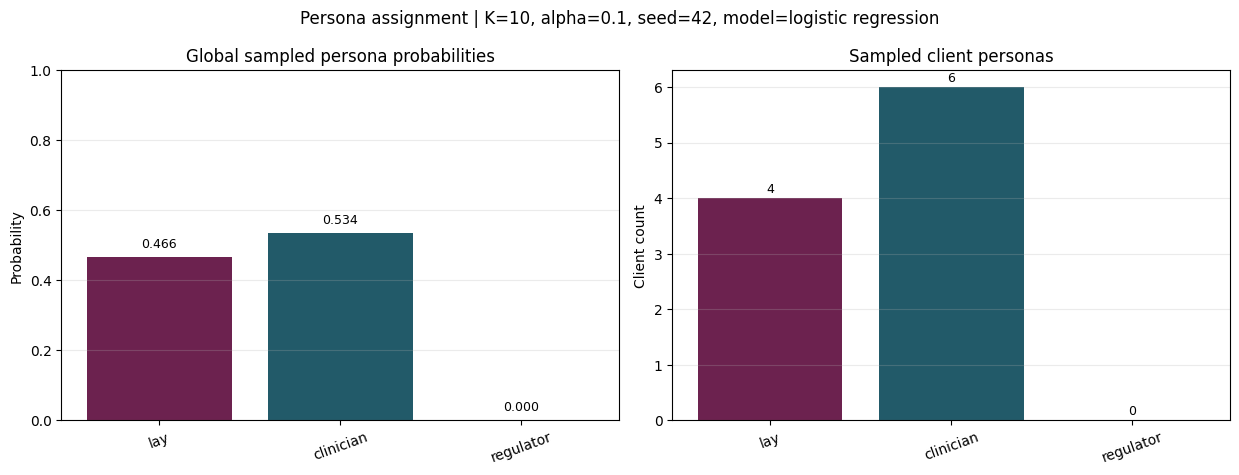

,client_id,persona,argmax_persona
0,client_000,lay,clinician
1,client_001,clinician,clinician
2,client_002,clinician,clinician
3,client_003,clinician,clinician
4,client_004,lay,clinician
5,client_005,lay,clinician
6,client_006,lay,clinician
7,client_007,clinician,clinician
8,client_008,clinician,clinician
9,client_009,clinician,clinician


### Cluster Alignment Diagnostics

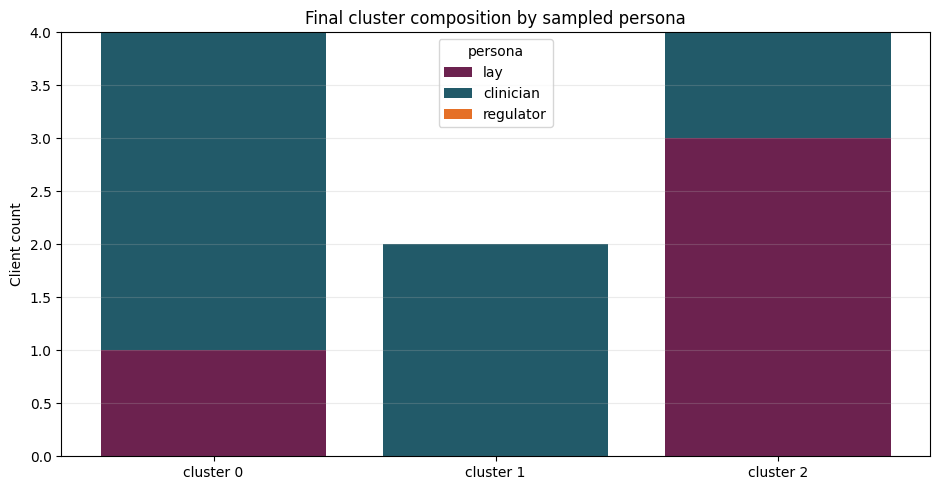

#### Persona-by-cluster contingency table

cluster_id,0,1,2
persona,,,
lay,1,0,3
clinician,3,2,1
regulator,0,0,0


#### Client-level sampled persona and final cluster assignment

,client_id,persona,argmax_persona,cluster_id
0,client_000,lay,clinician,2
1,client_001,clinician,clinician,0
2,client_002,clinician,clinician,0
3,client_003,clinician,clinician,1
4,client_004,lay,clinician,2
5,client_005,lay,clinician,0
6,client_006,lay,clinician,2
7,client_007,clinician,clinician,1
8,client_008,clinician,clinician,2
9,client_009,clinician,clinician,0


## K=10, alpha=10.0, seed=42, model=logistic regression

`run_id = federated-training-adult_income-20260503t135448936944+0000-logistic_regression-10clients-alpha10.0-seed42-ff564875d681`

### Pearson@3

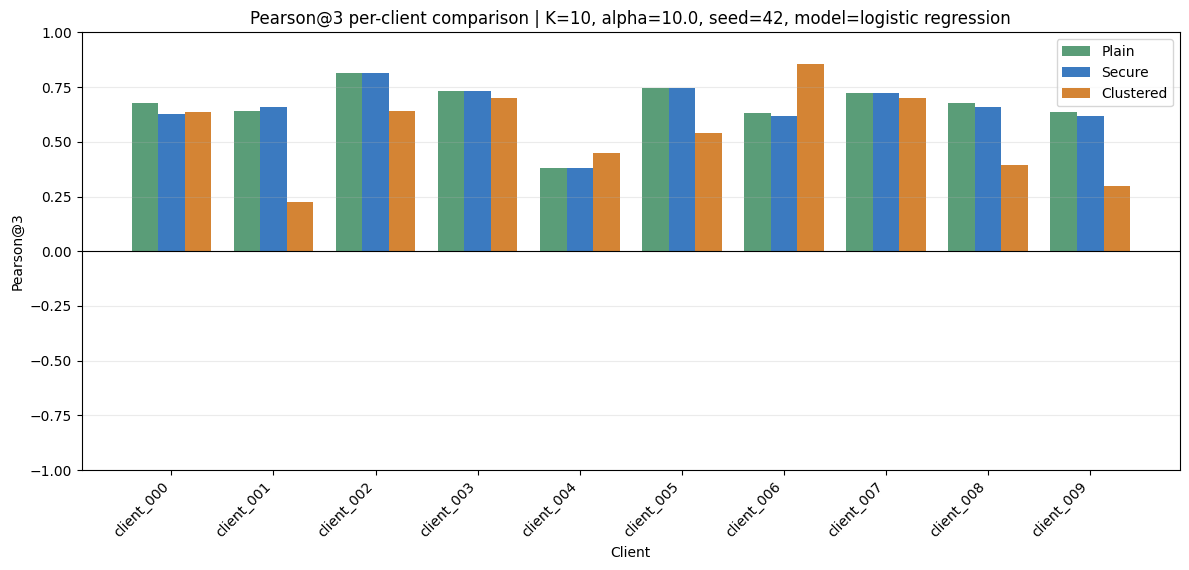

### Pearson@5

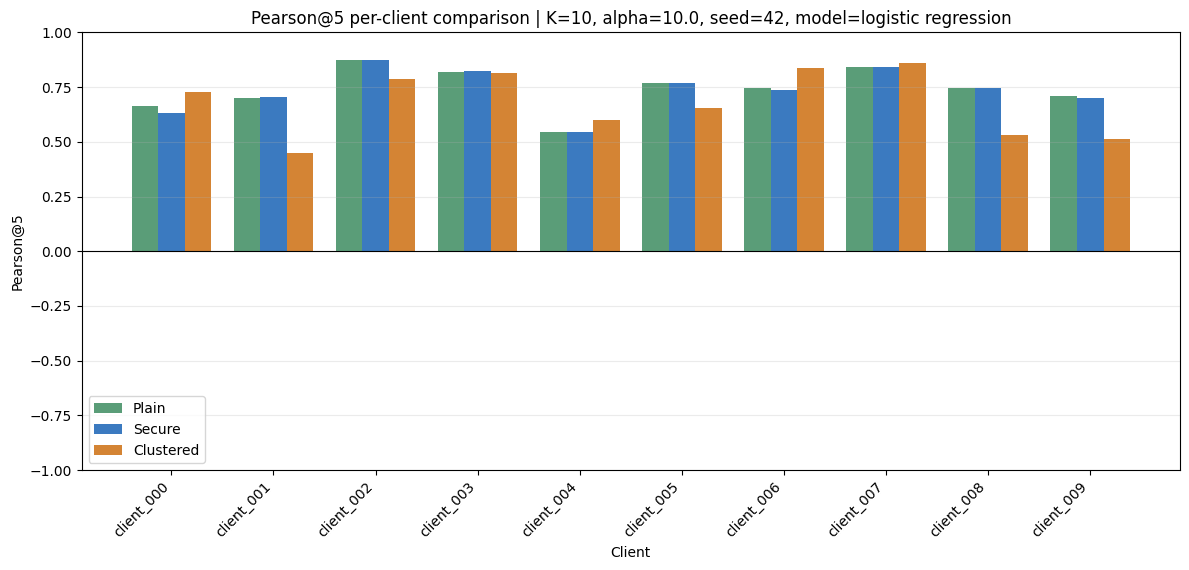

### Pearson@8

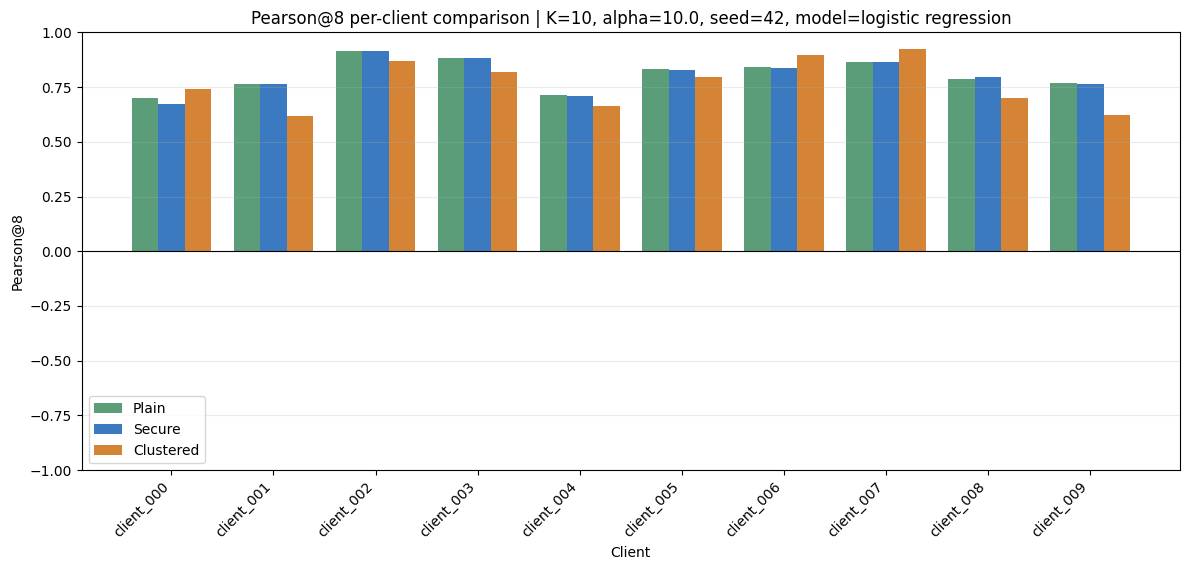

### Average Pearson@3, Pearson@5, and Pearson@8

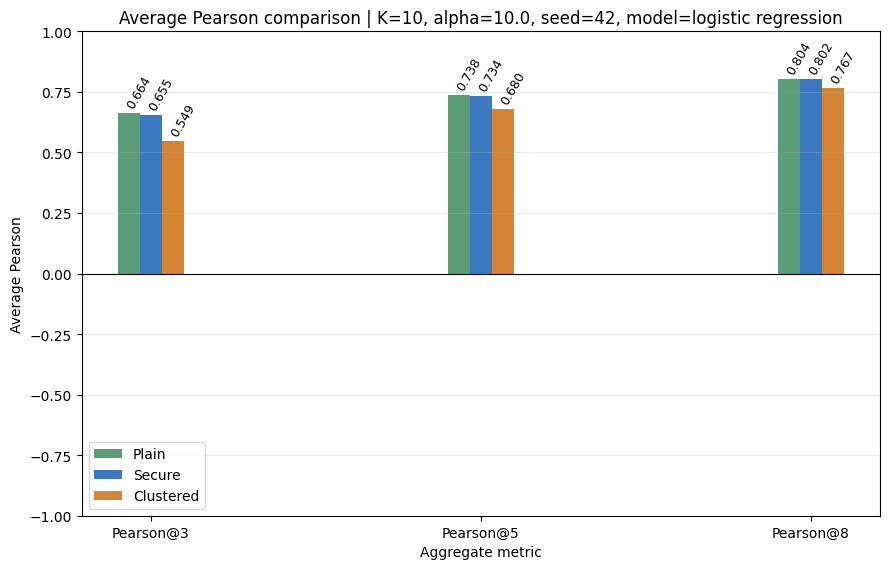

### Persona Assignment Diagnostics

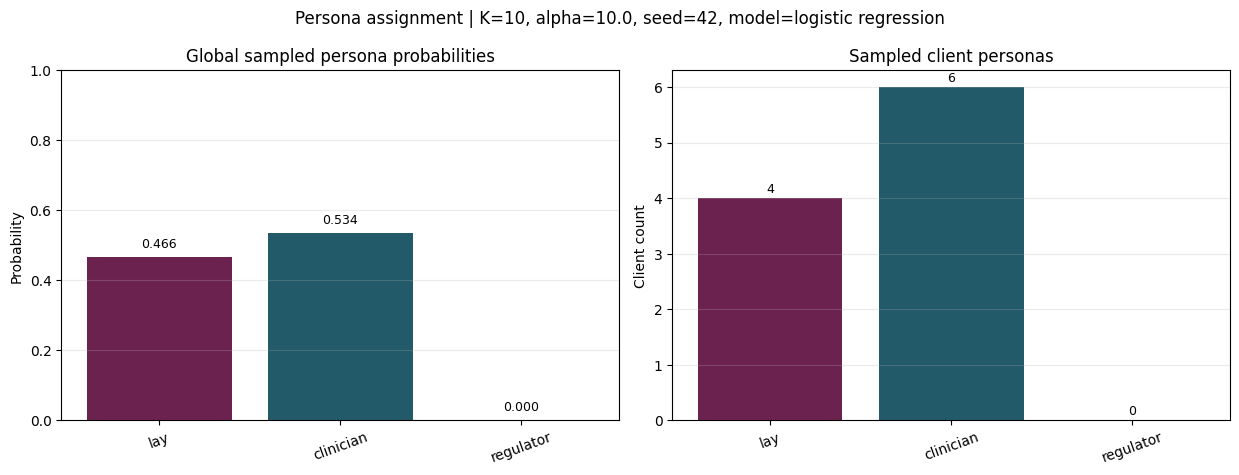

,client_id,persona,argmax_persona
0,client_000,lay,clinician
1,client_001,clinician,clinician
2,client_002,clinician,clinician
3,client_003,clinician,clinician
4,client_004,lay,clinician
5,client_005,lay,clinician
6,client_006,lay,clinician
7,client_007,clinician,clinician
8,client_008,clinician,clinician
9,client_009,clinician,clinician


### Cluster Alignment Diagnostics

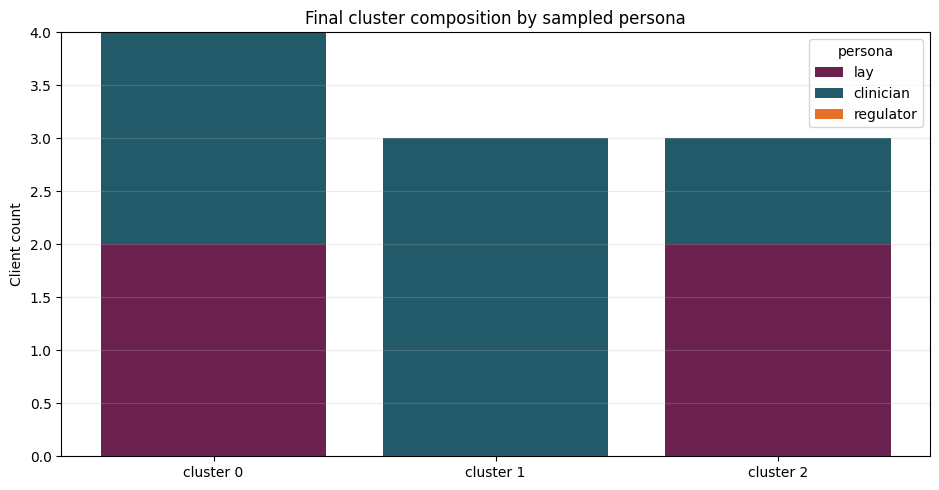

#### Persona-by-cluster contingency table

cluster_id,0,1,2
persona,,,
lay,2,0,2
clinician,2,3,1
regulator,0,0,0


#### Client-level sampled persona and final cluster assignment

,client_id,persona,argmax_persona,cluster_id
0,client_000,lay,clinician,2
1,client_001,clinician,clinician,0
2,client_002,clinician,clinician,1
3,client_003,clinician,clinician,1
4,client_004,lay,clinician,0
5,client_005,lay,clinician,0
6,client_006,lay,clinician,2
7,client_007,clinician,clinician,1
8,client_008,clinician,clinician,0
9,client_009,clinician,clinician,2


## K=15, alpha=0.1, seed=42, model=logistic regression

`run_id = federated-training-adult_income-20260503t135521322560+0000-logistic_regression-15clients-alpha0.1-seed42-f17b987d1290`

### Pearson@3

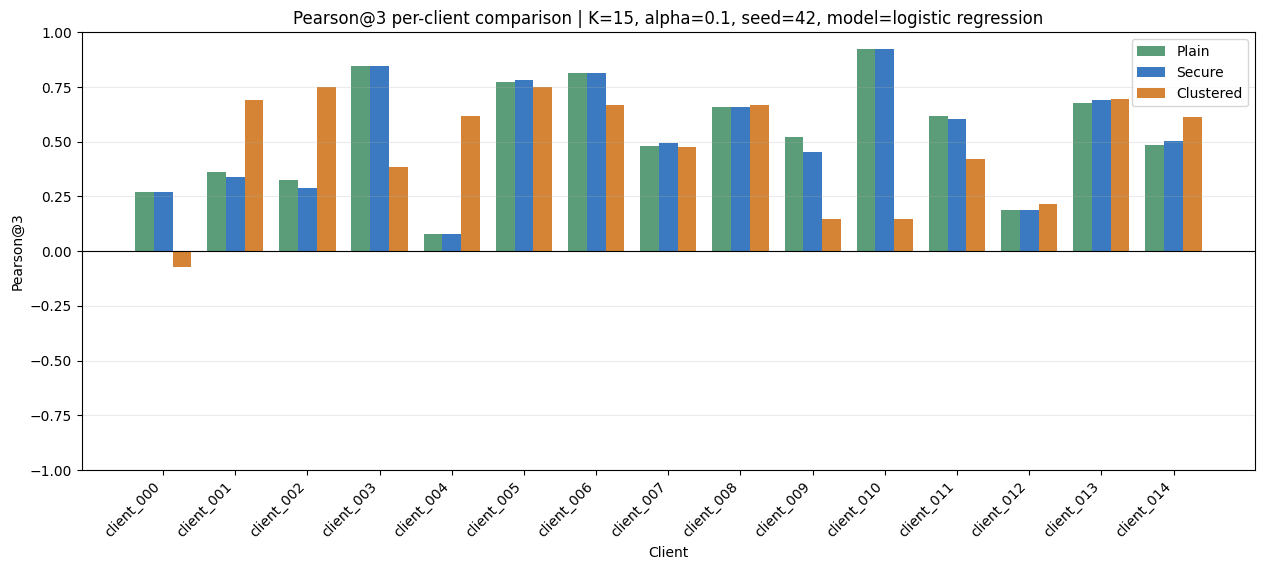

### Pearson@5

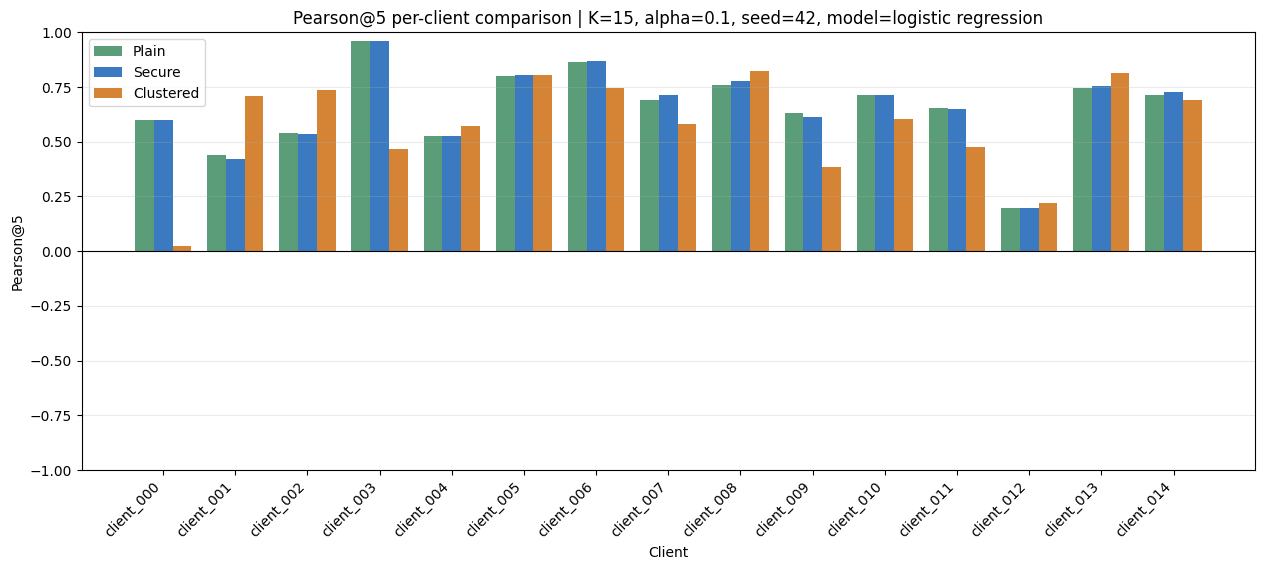

### Pearson@8

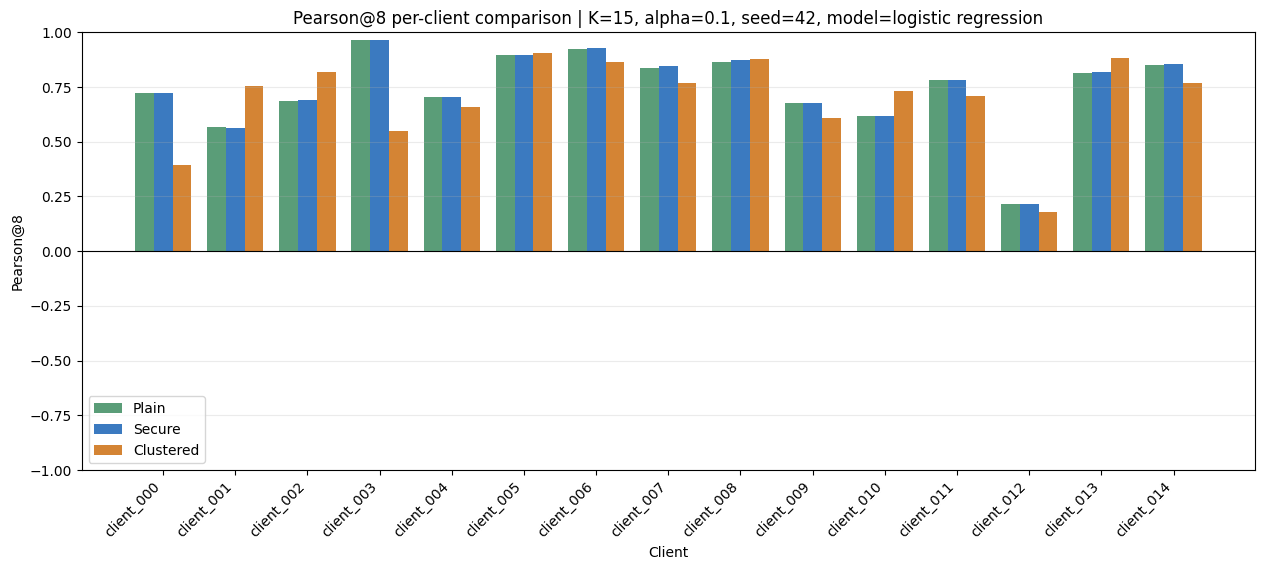

### Average Pearson@3, Pearson@5, and Pearson@8

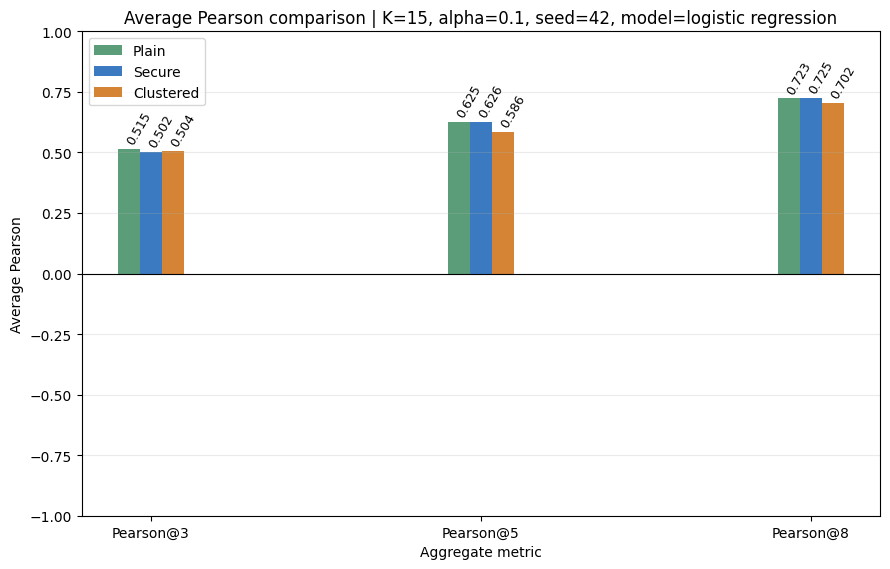

### Persona Assignment Diagnostics

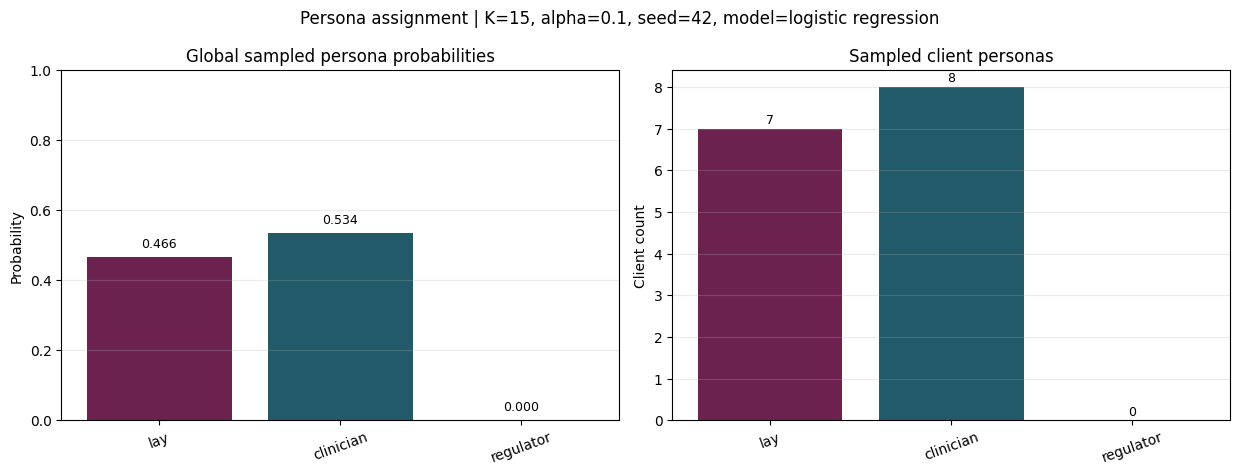

,client_id,persona,argmax_persona
0,client_000,lay,clinician
1,client_001,clinician,clinician
2,client_002,clinician,clinician
3,client_003,clinician,clinician
4,client_004,lay,clinician
5,client_005,lay,clinician
6,client_006,lay,clinician
7,client_007,clinician,clinician
8,client_008,clinician,clinician
9,client_009,clinician,clinician


### Cluster Alignment Diagnostics

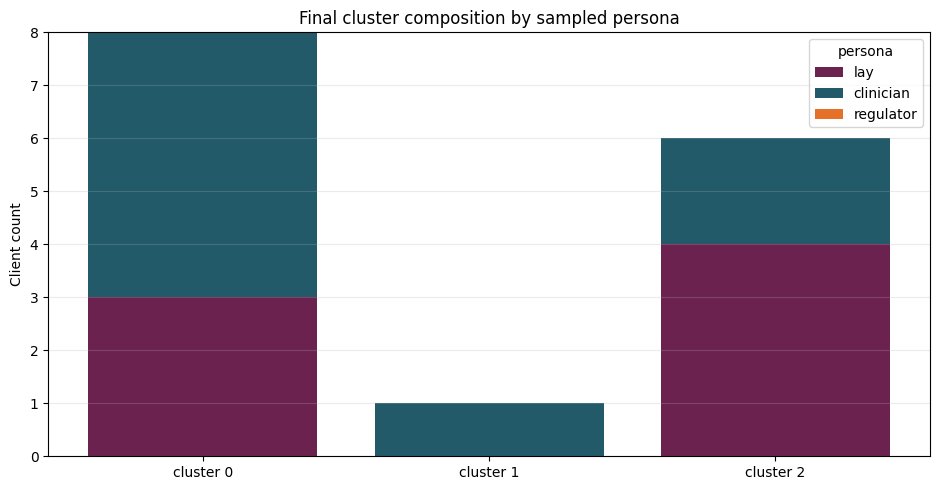

#### Persona-by-cluster contingency table

cluster_id,0,1,2
persona,,,
lay,3,0,4
clinician,5,1,2
regulator,0,0,0


#### Client-level sampled persona and final cluster assignment

,client_id,persona,argmax_persona,cluster_id
0,client_000,lay,clinician,2
1,client_001,clinician,clinician,0
2,client_002,clinician,clinician,0
3,client_003,clinician,clinician,0
4,client_004,lay,clinician,2
5,client_005,lay,clinician,2
6,client_006,lay,clinician,0
7,client_007,clinician,clinician,0
8,client_008,clinician,clinician,1
9,client_009,clinician,clinician,2


## K=15, alpha=1.0, seed=42, model=logistic regression

`run_id = federated-training-adult_income-20260503t135603131352+0000-logistic_regression-15clients-alpha1.0-seed42-a75fb8d8fee4`

### Pearson@3

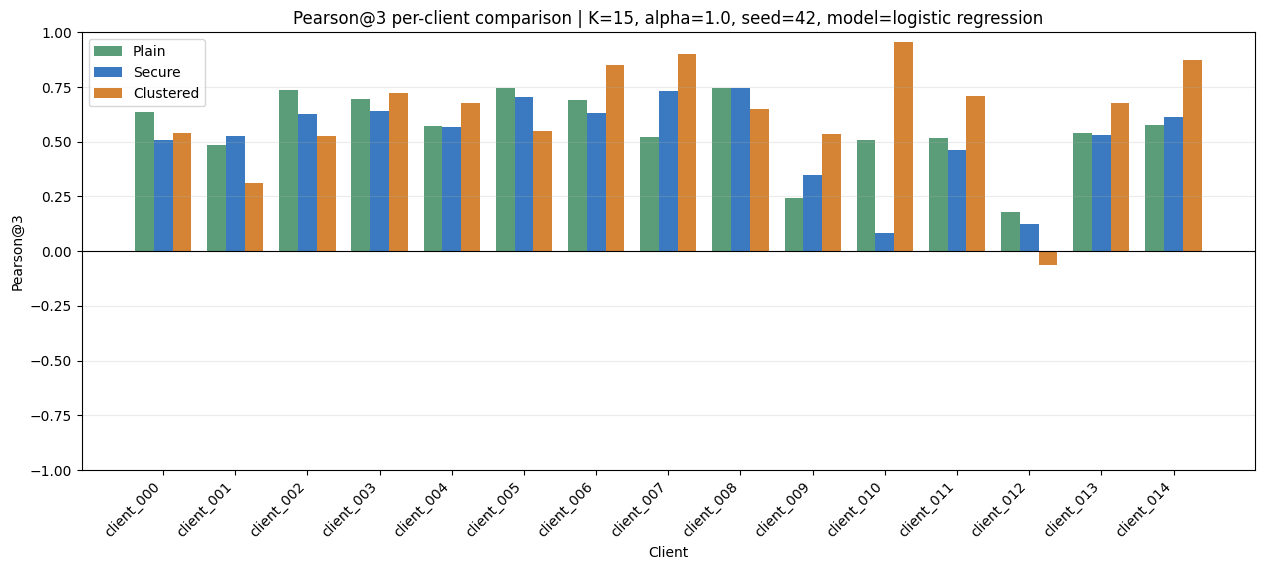

### Pearson@5

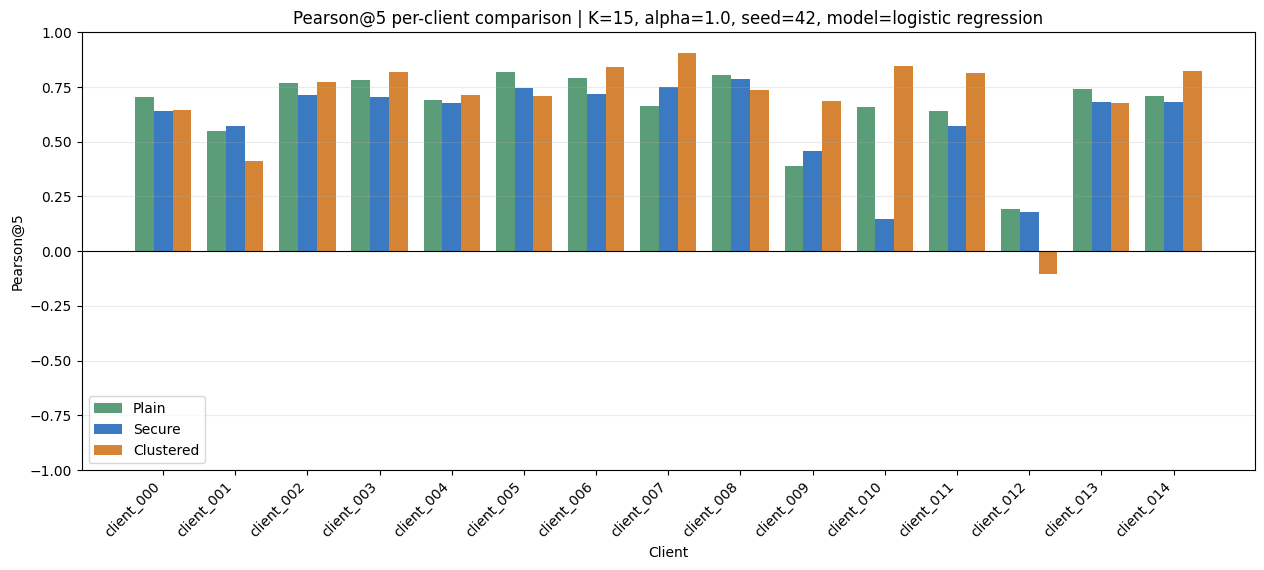

### Pearson@8

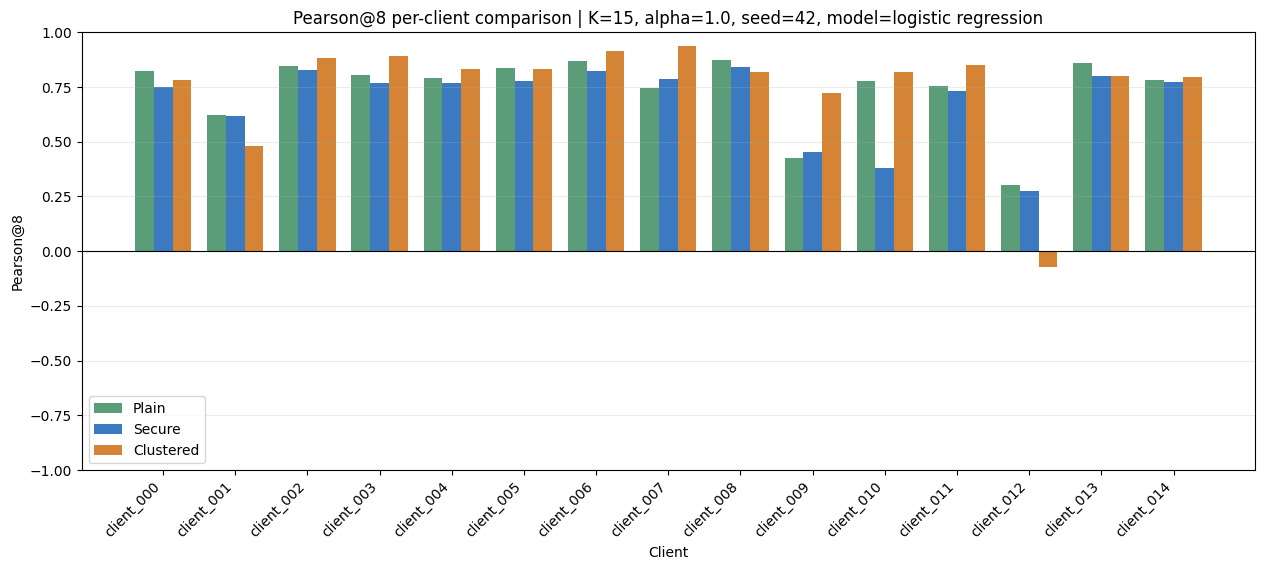

### Average Pearson@3, Pearson@5, and Pearson@8

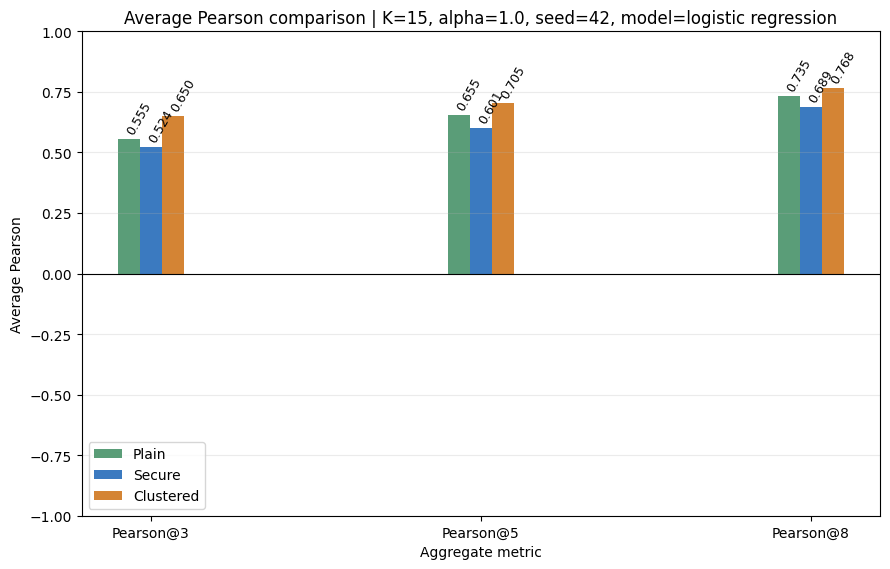

### Persona Assignment Diagnostics

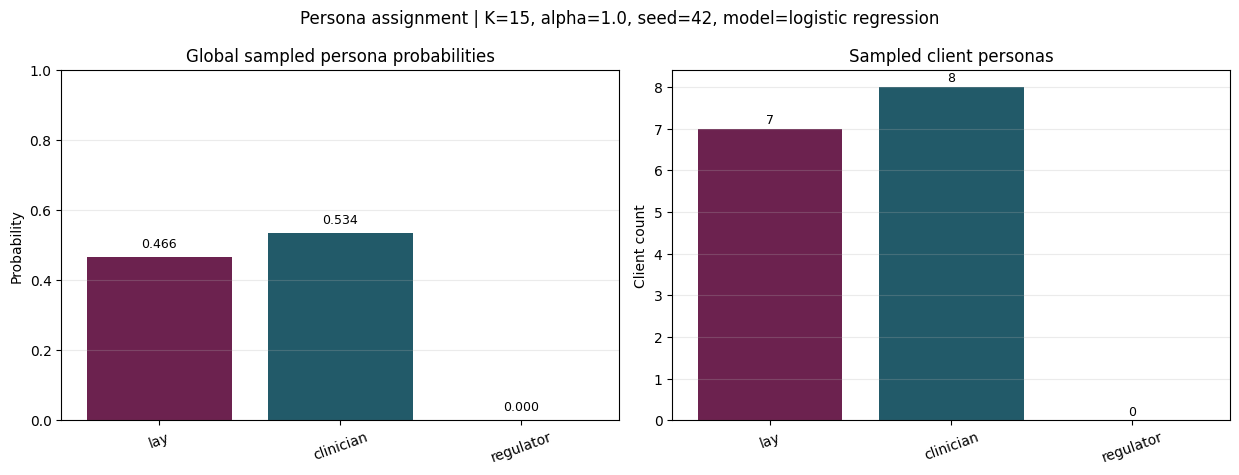

,client_id,persona,argmax_persona
0,client_000,lay,clinician
1,client_001,clinician,clinician
2,client_002,clinician,clinician
3,client_003,clinician,clinician
4,client_004,lay,clinician
5,client_005,lay,clinician
6,client_006,lay,clinician
7,client_007,clinician,clinician
8,client_008,clinician,clinician
9,client_009,clinician,clinician


### Cluster Alignment Diagnostics

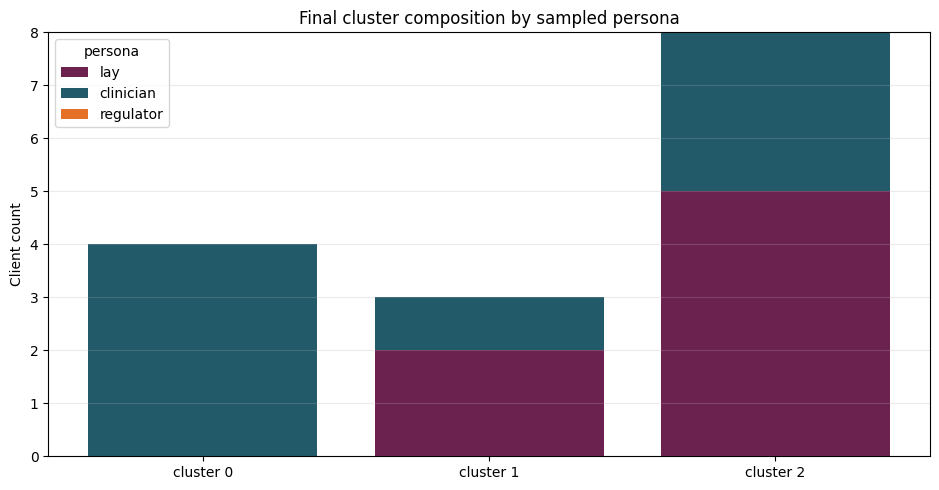

#### Persona-by-cluster contingency table

cluster_id,0,1,2
persona,,,
lay,0,2,5
clinician,4,1,3
regulator,0,0,0


#### Client-level sampled persona and final cluster assignment

,client_id,persona,argmax_persona,cluster_id
0,client_000,lay,clinician,1
1,client_001,clinician,clinician,2
2,client_002,clinician,clinician,1
3,client_003,clinician,clinician,0
4,client_004,lay,clinician,2
5,client_005,lay,clinician,2
6,client_006,lay,clinician,2
7,client_007,clinician,clinician,0
8,client_008,clinician,clinician,2
9,client_009,clinician,clinician,0


## K=15, alpha=10.0, seed=42, model=logistic regression

`run_id = federated-training-adult_income-20260503t135645220328+0000-logistic_regression-15clients-alpha10.0-seed42-dfa15b7a087a`

### Pearson@3

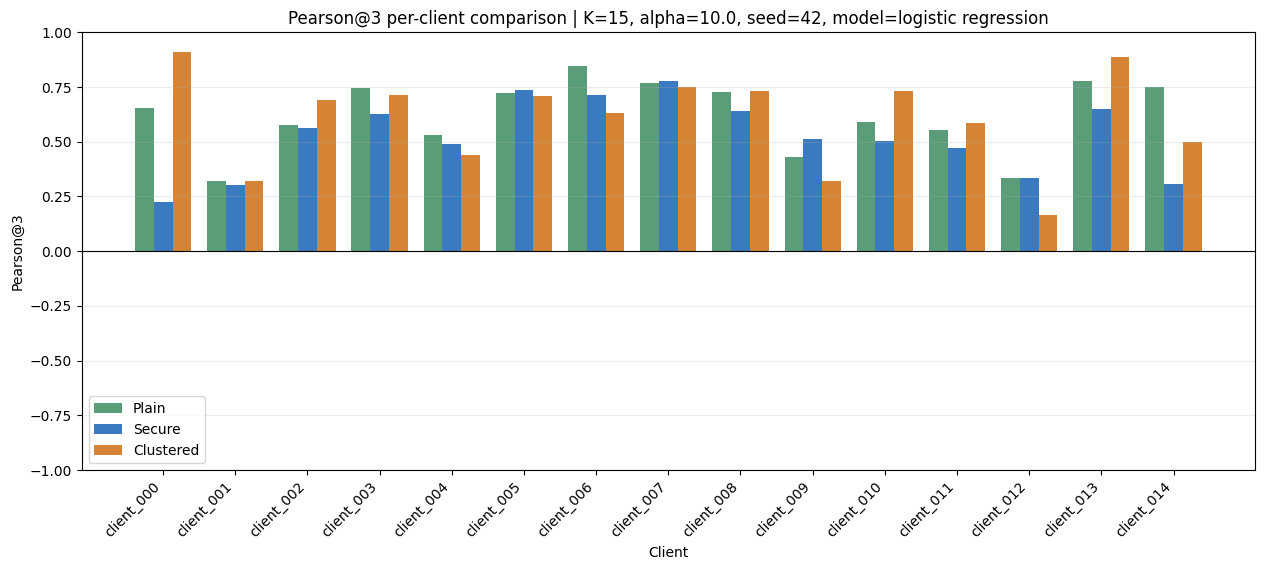

### Pearson@5

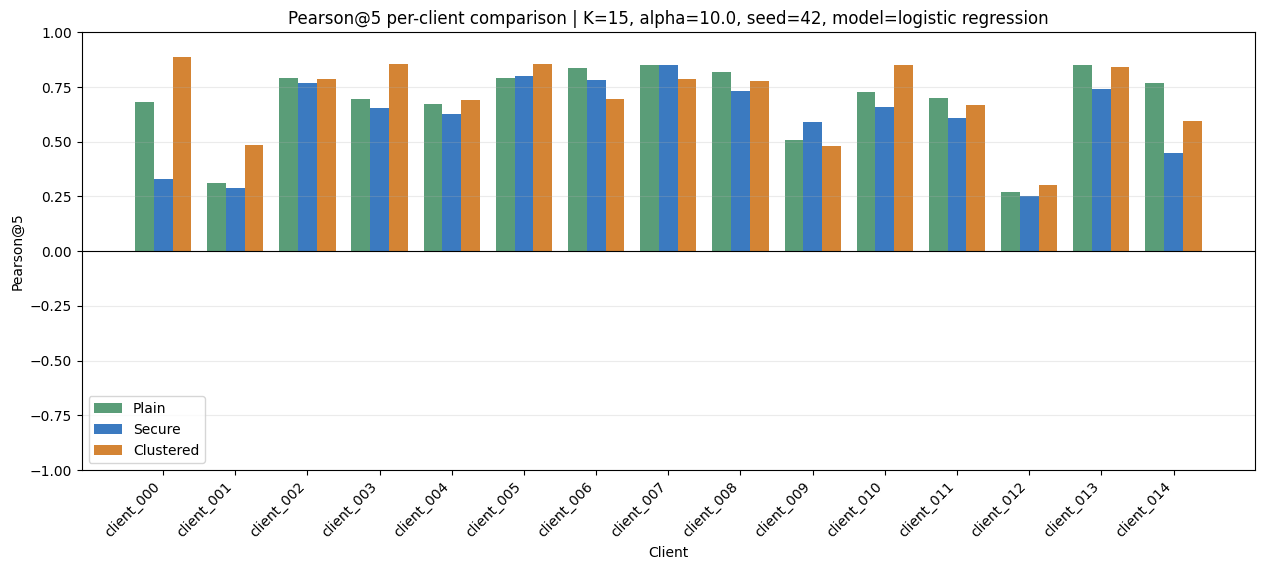

### Pearson@8

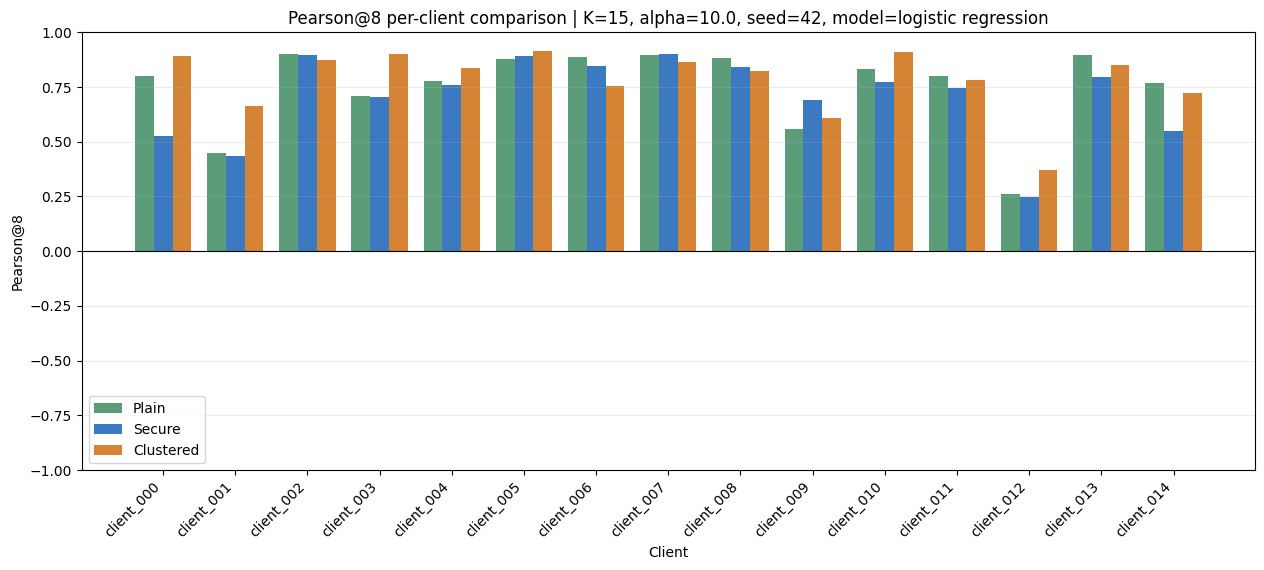

### Average Pearson@3, Pearson@5, and Pearson@8

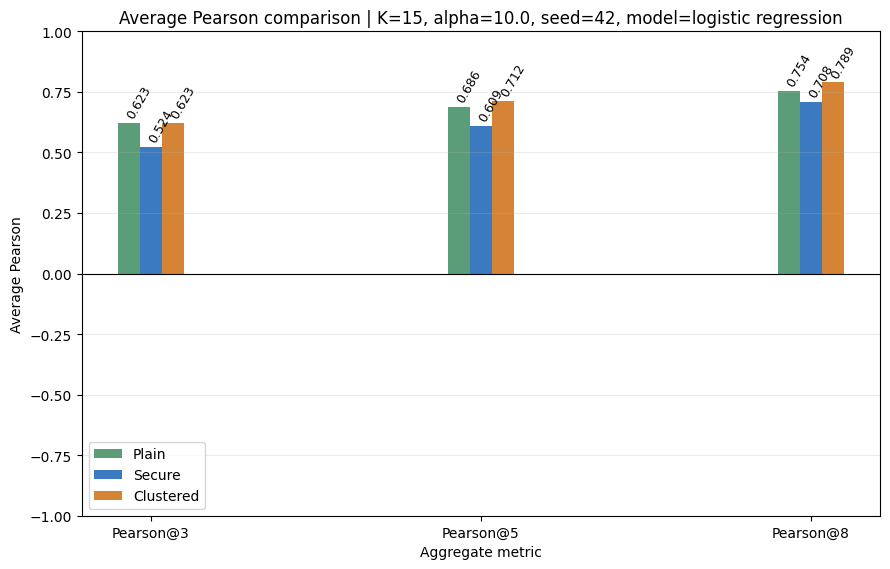

### Persona Assignment Diagnostics

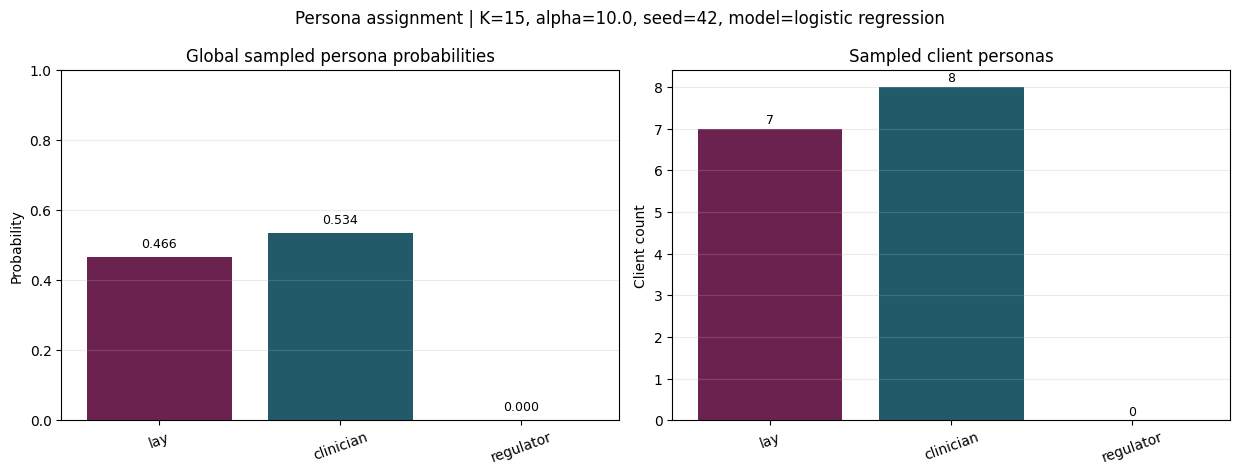

,client_id,persona,argmax_persona
0,client_000,lay,clinician
1,client_001,clinician,clinician
2,client_002,clinician,clinician
3,client_003,clinician,clinician
4,client_004,lay,clinician
5,client_005,lay,clinician
6,client_006,lay,clinician
7,client_007,clinician,clinician
8,client_008,clinician,clinician
9,client_009,clinician,clinician


### Cluster Alignment Diagnostics

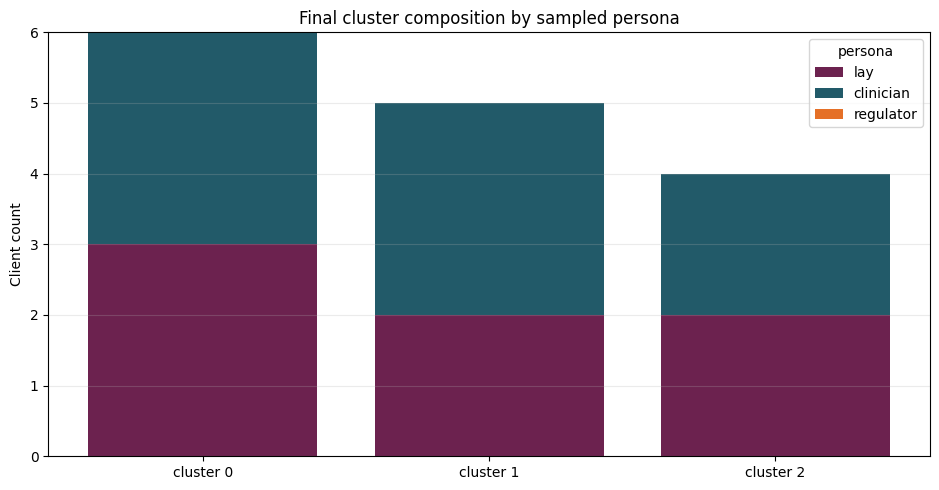

#### Persona-by-cluster contingency table

cluster_id,0,1,2
persona,,,
lay,3,2,2
clinician,3,3,2
regulator,0,0,0


#### Client-level sampled persona and final cluster assignment

,client_id,persona,argmax_persona,cluster_id
0,client_000,lay,clinician,2
1,client_001,clinician,clinician,1
2,client_002,clinician,clinician,1
3,client_003,clinician,clinician,2
4,client_004,lay,clinician,0
5,client_005,lay,clinician,0
6,client_006,lay,clinician,2
7,client_007,clinician,clinician,0
8,client_008,clinician,clinician,1
9,client_009,clinician,clinician,0


In [4]:
for run_config in RUN_CONFIGS:
    render_run(run_config)
